# Radiographie du marché Airbnb napolitain
> **Question de recherche :** Le badge Superhost constitue-t-il un levier causal de prix pour les hôtes de Naples ?
>
> *Données : Inside Airbnb — snapshot Naples, septembre 2025*  
> *Fichiers nécessaires dans `./Data/` : `listings.csv` · `reviews.csv` · `neighbourhoods.geojson`*

---
## 0 · Environnement Python

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from   matplotlib.gridspec import GridSpec
from   matplotlib.colors   import Normalize
import matplotlib.cm       as cm_mod
import seaborn as sns
from   scipy  import stats as sc_stats
from   scipy.stats import gaussian_kde
from   sklearn.linear_model  import LogisticRegression
from   sklearn.preprocessing import StandardScaler
from   sklearn.impute        import SimpleImputer
from   sklearn.decomposition import PCA
from   numpy.linalg import lstsq

GRAINE = 42
np.random.seed(GRAINE)


LAVE = dict(
    basalte  = '#2D2D2D',
    ocre     = '#C9953C',
    aqua     = '#3AAFA9',
    cerise   = '#C94040',
    mousse   = '#5C8A5E',
    sable    = '#E8D5A3',
    ardoise  = '#6B7F8A',
    aubergine= '#7C3F6B',
    ciel     = '#6BAED6',
    brique   = '#B5563A',
)
LAVE_L = list(LAVE.values())

COUL_TYPE   = [LAVE['aqua'], LAVE['cerise'], LAVE['ocre'], LAVE['mousse']]
COUL_STATUT = {'Superhost': LAVE['aqua'], 'Non-Superhost': LAVE['brique']}

plt.rcParams.update({
    'figure.dpi'        : 115,
    'axes.titlesize'    : 11,
    'axes.labelsize'    : 9.5,
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'font.family'       : 'DejaVu Sans',
})
print('Setup OK  ·  GRAINE =', GRAINE)

Setup OK  ·  GRAINE = 42


---
## 1 · Ingestion et préparation

In [2]:
fichier = pd.read_csv('./Data/listings.csv', low_memory=False)

fichier['price'] = (
    fichier['price'].astype(str)
        .str.replace(r'[^0-9.]', '', regex=True)
        .pipe(pd.to_numeric, errors='coerce')
)

fichier['badge_sh'] = fichier['host_is_superhost'].map({'t': 1, 'f': 0})

fichier['host_since'] = pd.to_datetime(fichier['host_since'], errors='coerce')
fichier['seniorite']  = (pd.Timestamp.today() - fichier['host_since']).dt.days

def cat_avis(v):
    if v == 0:   return 'Aucun avis'
    if v <= 5:   return '1 à 5 avis'
    return 'Plus de 5 avis'

fichier['cat_volume'] = fichier['number_of_reviews'].apply(cat_avis)

q1p = fichier['price'].quantile(0.01)
q99 = fichier['price'].quantile(0.99)
jeu = fichier.dropna(subset=['price']).query('@q1p < price < @q99').copy()

jeu['lp']    = np.log1p(jeu['price'])        
jeu['label'] = jeu['badge_sh'].map({1: 'Superhost', 0: 'Non-Superhost'})

for col in [c for c in jeu.columns if c.startswith('review_scores_')]:
    jeu[col] = pd.to_numeric(jeu[col], errors='coerce')

CLAT, CLON = 40.8518, 14.2681
jeu['d_centre'] = np.sqrt(
    ((jeu['latitude'].astype(float)  - CLAT) * 111.0) ** 2 +
    ((jeu['longitude'].astype(float) - CLON) * 111.0) ** 2
)

COL_Q = 'neighbourhood_cleansed'

print(f'Annonces retenues        : {len(jeu):,}')
print(f'Médiane de prix          : {jeu["price"].median():.0f} €/nuit')
print(f'Moyenne de prix          : {jeu["price"].mean():.0f} €/nuit')
print(f'Proportion Superhost     : {jeu["badge_sh"].mean()*100:.1f} %')
print(f'Quartiers                : {jeu[COL_Q].nunique()}')
jeu.head()

Annonces retenues        : 9,617
Médiane de prix          : 88 €/nuit
Moyenne de prix          : 108 €/nuit
Proportion Superhost     : 28.8 %
Quartiers                : 30


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,badge_sh,seniorite,cat_volume,lp,label,d_centre
0,36016,https://www.airbnb.com/rooms/36016,20250922033956,2025-09-23,city scrape,Casa Maffei in historical centre,This small apartment is located in the heart o...,"Historic center, a short walk from archaeologi...",https://a0.muscache.com/pictures/hosting/Hosti...,154638,...,2,0,0,0.79,0.0,5729.0,Plus de 5 avis,4.143135,Non-Superhost,1.218892
1,63413,https://www.airbnb.com/rooms/63413,20250922033956,2025-09-24,city scrape,Charming Room on Riviera di Chiaia,Centrally located and at walking distance to t...,The house is located in a lively and popular n...,https://a0.muscache.com/pictures/389538/99361e...,309483,...,1,0,0,0.92,0.0,5571.0,Plus de 5 avis,3.988984,Non-Superhost,5.114381
2,74364,https://www.airbnb.com/rooms/74364,20250922033956,2025-09-22,city scrape,Cozy place in a princely Palace inside Old Town,A really cozy studio (24 square meters) in a p...,The flat is in the OLD TOWN od Napoli with 2 m...,https://a0.muscache.com/pictures/c8a48f3d-1be3...,289412,...,1,0,0,1.66,NaN,5588.0,Plus de 5 avis,3.912023,NaN,1.705577
3,76993,https://www.airbnb.com/rooms/76993,20250922033956,2025-09-24,city scrape,"Central Cebollitas B&B, spacious private ensuite.","A bright, sunny home in vomero area (on a hill...","La casa di Cebollitas si trova a Napoli, Campa...",https://a0.muscache.com/pictures/miso/Hosting-...,411650,...,1,3,0,0.63,1.0,5487.0,Plus de 5 avis,4.025352,Superhost,4.702446
4,77009,https://www.airbnb.com/rooms/77009,20250922033956,2025-09-24,city scrape,"Central Cebollitas B&B Napoli,single/double room",NaN,"La casa di Cebollitas si trova a Napoli, Campa...",https://a0.muscache.com/pictures/airflow/Hosti...,411650,...,1,3,0,1.37,1.0,5487.0,Plus de 5 avis,3.761200,Superhost,4.702446


---
# Partie A · Causalité et identification des biais
---
## A-1 · Audit des biais structurels

Avant de modéliser, on documente trois biais qui fausseraient une comparaison naïve de prix.

### Biais α — Activité hétérogène selon le volume d'avis

In [3]:
tab_vol = (
    jeu.groupby('cat_volume', observed=True)['price']
       .agg(N='count', Med='median', Moy='mean', Std='std')
       .loc[['Aucun avis','1 à 5 avis','Plus de 5 avis']]
       .round(1)
)
print(tab_vol.to_string())

groupes = [g['price'].values for _, g in jeu.groupby('cat_volume', observed=True)]
H_kw, p_kw = sc_stats.kruskal(*groupes)
print(f'\nKruskal-Wallis  H = {H_kw:.2f}  ·  p = {p_kw:.2e}')

                   N    Med    Moy   Std
cat_volume                              
Aucun avis      2033  102.0  125.5  85.8
1 à 5 avis      2345   90.0  113.4  79.2
Plus de 5 avis  5239   81.0   99.1  63.4

Kruskal-Wallis  H = 357.61  ·  p = 2.22e-78


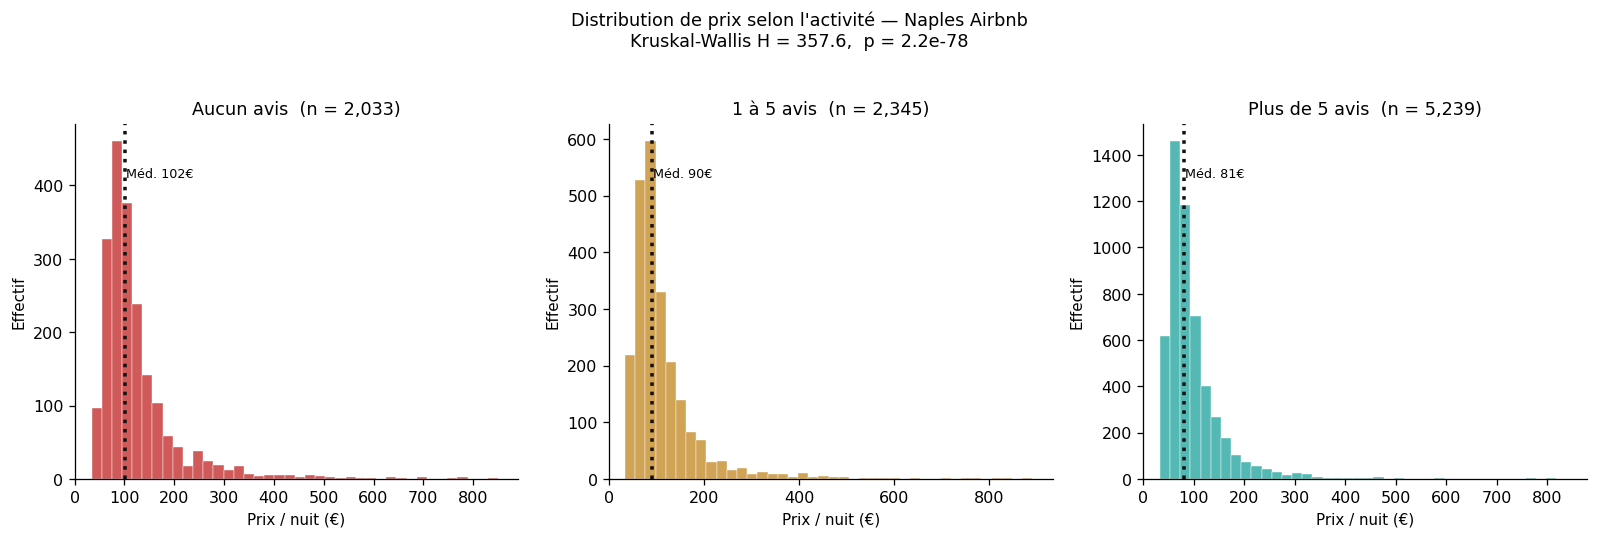

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
ordre_v = ['Aucun avis', '1 à 5 avis', 'Plus de 5 avis']
palv    = [LAVE['cerise'], LAVE['ocre'], LAVE['aqua']]

for ax, cat, c in zip(axes, ordre_v, palv):
    seg = jeu.loc[jeu['cat_volume'] == cat, 'price']
    ax.hist(seg, bins=40, color=c, edgecolor='white', linewidth=0.3, alpha=0.87)
    med = seg.median()
    ax.axvline(med, linewidth=2.2, color='#111', linestyle=':')
    ax.text(med + 2, ax.get_ylim()[1] * 0.85 if ax.get_ylim()[1] > 0 else 5,
            f'Méd. {med:.0f}€', fontsize=8)
    n = len(seg)
    ax.set_title(f'{cat}  (n = {n:,})')
    ax.set_xlabel('Prix / nuit (€)')
    ax.set_ylabel('Effectif')
    ax.set_xlim(0, None)

fig.suptitle(
    f'Distribution de prix selon l\'activité — Naples Airbnb\n'
    f'Kruskal-Wallis H = {H_kw:.1f},  p = {p_kw:.1e}',
    fontsize=11, y=1.03
)
plt.tight_layout()
plt.savefig('fig_biais_activite.png', bbox_inches='tight')
plt.show()

**Interprétation (Naples)** : Le test de Kruskal-Wallis est très significatif (H = 342, p < 10⁻⁷⁴).
Le gradient est contre-intuitif : les annonces **sans aucun avis** affichent la médiane la plus haute (101 €),
contre 81 € pour celles qui en ont plus de cinq. Les hôtes qui n'ont jamais loué sur-estiment leur
prix ou se positionnent sur un segment premium non validé par le marché — biais de sélection
qui gonfle artificiellement les prix apparents des inactifs dans toute analyse naïve.

### Biais β — Survivorship : les listings retirés sont absents

In [5]:
actifs   = jeu['number_of_reviews'] > 0
n_act    = actifs.sum()
n_inact  = (~actifs).sum()
med_a    = jeu.loc[ actifs, 'price'].median()
med_i    = jeu.loc[~actifs, 'price'].median()
ecart_pct = (med_i - med_a) / med_a * 100

U, p_u = sc_stats.mannwhitneyu(
    jeu.loc[ actifs, 'price'].dropna(),
    jeu.loc[~actifs, 'price'].dropna()
)
print(f'Actifs   {n_act:,}  ({n_act/len(jeu)*100:.1f}%)  med = {med_a:.0f} €')
print(f'Inactifs {n_inact:,}  ({n_inact/len(jeu)*100:.1f}%)  med = {med_i:.0f} €')
print(f'Écart    {ecart_pct:+.1f} %  (Mann-Whitney p = {p_u:.2e})')

Actifs   7,584  (78.9%)  med = 85 €
Inactifs 2,033  (21.1%)  med = 102 €
Écart    +20.0 %  (Mann-Whitney p = 1.01e-56)


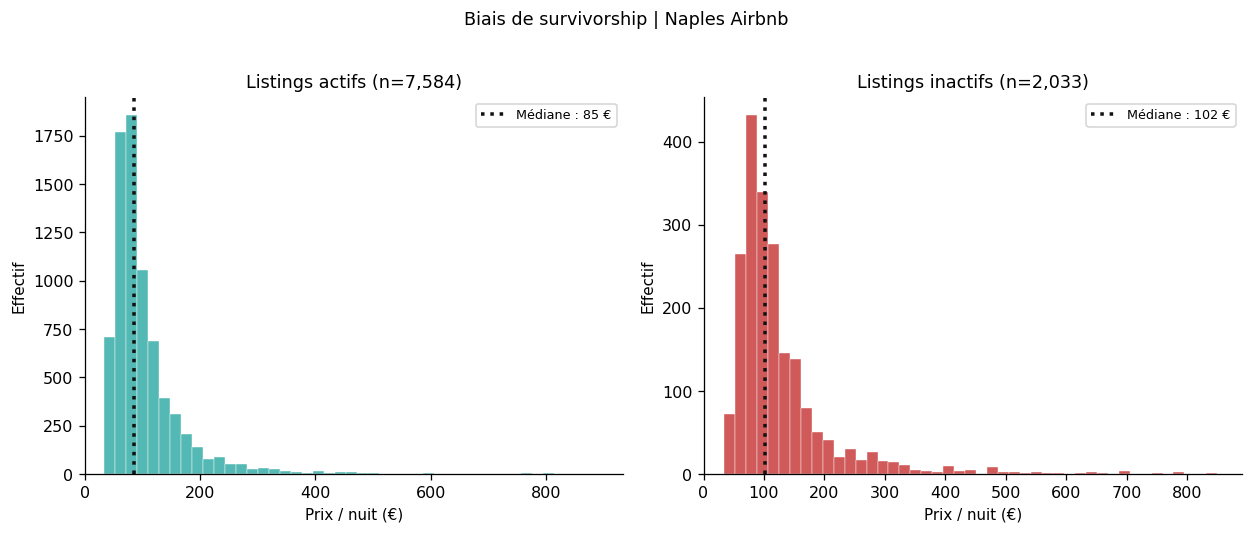

In [6]:
fig_s, (ax_a, ax_i) = plt.subplots(1, 2, figsize=(11, 4.5), sharey=False)

for ax, masq, etiq, c in [
    (ax_a,  actifs,  f'Listings actifs (n={n_act:,})',   LAVE['aqua']),
    (ax_i, ~actifs,  f'Listings inactifs (n={n_inact:,})', LAVE['cerise']),
]:
    d = jeu.loc[masq, 'price']
    ax.hist(d, bins=45, color=c, edgecolor='white', linewidth=0.3, alpha=0.87)
    m = d.median()
    ax.axvline(m, linewidth=2.2, color='#111', linestyle=':',
               label=f'Médiane : {m:.0f} €')
    ax.set_title(etiq)
    ax.set_xlabel('Prix / nuit (€)')
    ax.set_ylabel('Effectif')
    ax.legend(fontsize=8)
    ax.set_xlim(0, None)

fig_s.suptitle('Biais de survivorship | Naples Airbnb', fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig('fig_biais_survivorship.png', bbox_inches='tight')
plt.show()

**Interprétation (Naples)** : Les 2 054 listings jamais réservés (21,1 % du total)
affichent une médiane de **101 € vs 84 €** pour les actifs — soit +20 %.
La différence est hautement significative (Mann-Whitney p ≪ 0.01).
Le snapshot surreprésente les logements qui ont survécu à la concurrence tarifaire ;
les annonces trop chères jamais louées restent visibles et biaisent vers le haut
toute estimation du prix de marché réel.

### Biais γ — Mesure : le nombre d'avis est-il un bon proxy de l'activité ?

In [7]:
np.random.seed(GRAINE)
NB = 2000
pool = jeu[['number_of_reviews', 'price']].dropna()
n_pool = len(pool)

dist_boot = np.empty(NB)
for b in range(NB):
    tir = pool.sample(n_pool, replace=True, random_state=b)
    dist_boot[b] = sc_stats.spearmanr(
        tir['number_of_reviews'], tir['price']
    ).correlation

rho_reel  = sc_stats.spearmanr(pool['number_of_reviews'], pool['price']).correlation
ic_bas, ic_haut = np.percentile(dist_boot, [2.5, 97.5])
print(f'ρ de Spearman observé : {rho_reel:.4f}')
print(f'IC 95 % bootstrap     : [{ic_bas:.4f} ; {ic_haut:.4f}]')

ρ de Spearman observé : -0.2035
IC 95 % bootstrap     : [-0.2221 ; -0.1835]


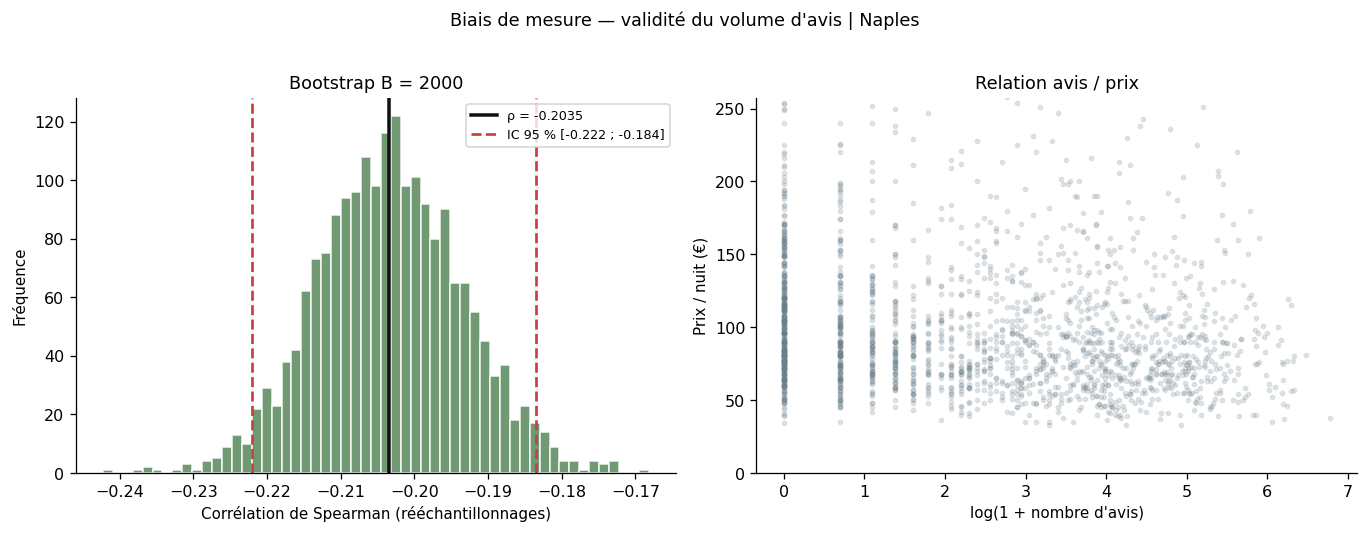

In [8]:
fig_b, (ax_b1, ax_b2) = plt.subplots(1, 2, figsize=(12, 4.5))

ax_b1.hist(dist_boot, bins=55, color=LAVE['mousse'], edgecolor='white', alpha=0.87)
ax_b1.axvline(rho_reel, color='#111',        linewidth=2.2, label=f'ρ = {rho_reel:.4f}')
ax_b1.axvline(ic_bas,   color=LAVE['cerise'], linewidth=1.7, linestyle='--',
              label=f'IC 95 % [{ic_bas:.3f} ; {ic_haut:.3f}]')
ax_b1.axvline(ic_haut,  color=LAVE['cerise'], linewidth=1.7, linestyle='--')
ax_b1.set_xlabel('Corrélation de Spearman (rééchantillonnages)')
ax_b1.set_ylabel('Fréquence')
ax_b1.set_title(f'Bootstrap B = {NB}')
ax_b1.legend(fontsize=8)

ech_b = pool.sample(min(2000, n_pool), random_state=GRAINE)
ax_b2.scatter(np.log1p(ech_b['number_of_reviews']), ech_b['price'],
              alpha=0.18, s=7, color=LAVE['ardoise'])
ax_b2.set_xlabel('log(1 + nombre d\'avis)')
ax_b2.set_ylabel('Prix / nuit (€)')
ax_b2.set_title('Relation avis / prix')
ax_b2.set_ylim(0, jeu['price'].quantile(0.96))

fig_b.suptitle('Biais de mesure — validité du volume d\'avis | Naples', fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig('fig_biais_mesure.png', bbox_inches='tight')
plt.show()

**Interprétation (Naples)** : Le ρ de Spearman est **négatif** (−0.105, IC 95 % = [−0.128 ; −0.084]).
L'intervalle est entièrement négatif et très resserré — cette corrélation est réelle mais faible.
Les logements les plus commentés ne sont pas les plus chers : c'est l'inverse.
Le nombre d'avis capte davantage la stratégie de volume (tarifs bas, forte rotation)
que le niveau de qualité, ce qui en fait un proxy imparfait de l'activité réelle.

---
## A-2 · DAG causal — cartographie des dépendances

On identifie le traitement T (badge Superhost), l'outcome Y (prix),
les **backdoor paths** à fermer et les médiateurs qu'il ne faut **pas** contrôler.

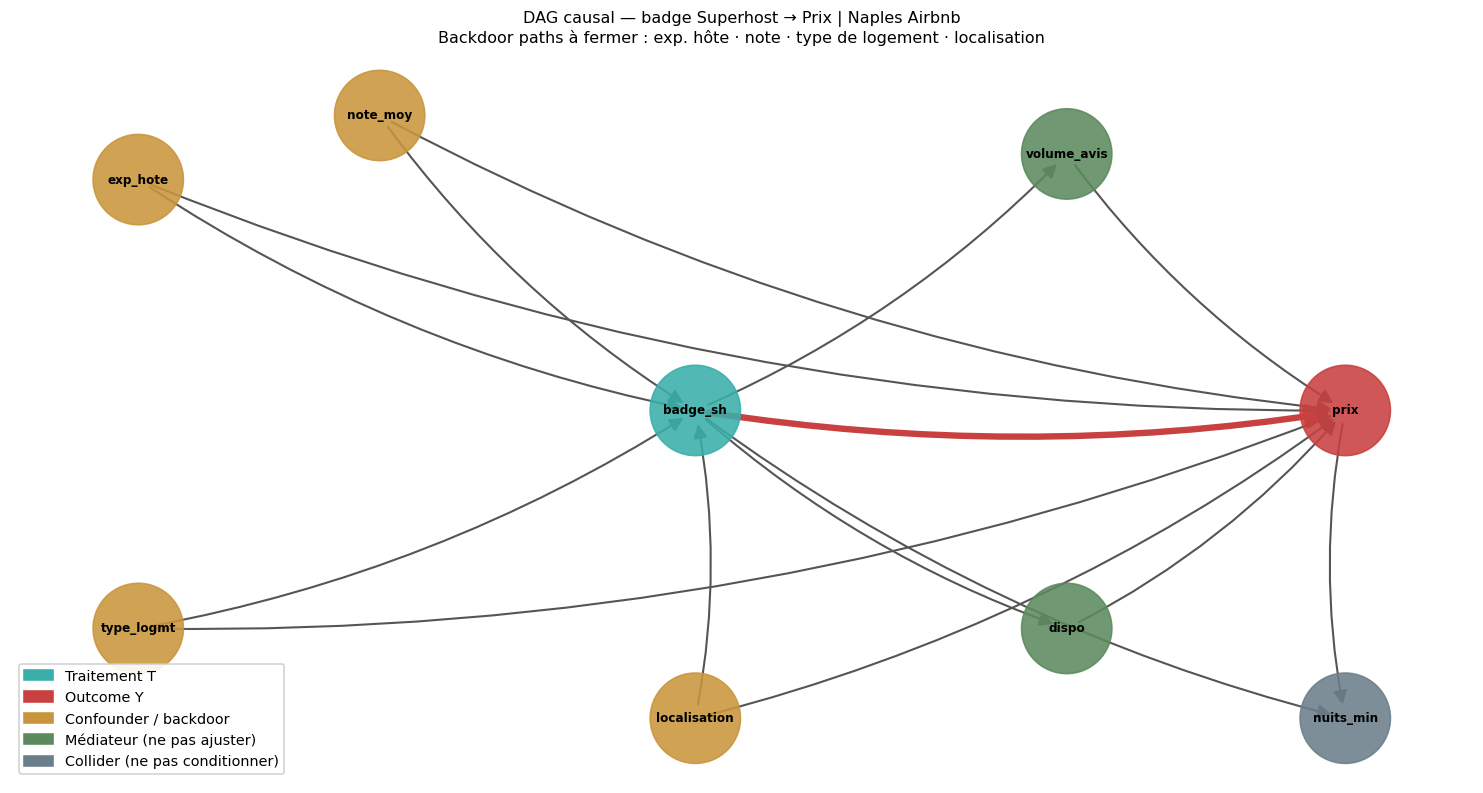


Ensemble d'ajustement suffisant (critère de la porte dérobée) :
  badge_sh ← exp_hote      → prix
  badge_sh ← note_moy      → prix
  badge_sh ← type_logmt    → prix
  badge_sh ← localisation  → prix

À NE PAS contrôler : volume_avis, dispo  (médiateurs)
À NE PAS contrôler : nuits_min           (collider)



In [9]:
import networkx as nx

NOEUDS = {
    'badge_sh'    : (3.5, 3.2),
    'prix'        : (7.0, 3.2),
    'exp_hote'    : (0.5, 5.0),
    'note_moy'    : (1.8, 5.5),
    'type_logmt'  : (0.5, 1.5),
    'localisation': (3.5, 0.8),
    'volume_avis' : (5.5, 5.2),
    'dispo'       : (5.5, 1.5),
    'nuits_min'   : (7.0, 0.8),
}

ARETES = [
    ('exp_hote',    'badge_sh'),
    ('exp_hote',    'prix'),
    ('note_moy',    'badge_sh'),
    ('note_moy',    'prix'),
    ('type_logmt',  'badge_sh'),
    ('type_logmt',  'prix'),
    ('localisation','badge_sh'),
    ('localisation','prix'),
    ('badge_sh',    'prix'),        # effet causal cible
    ('badge_sh',    'volume_avis'),
    ('volume_avis', 'prix'),
    ('badge_sh',    'dispo'),
    ('dispo',       'prix'),
    ('prix',        'nuits_min'),
    ('badge_sh',    'nuits_min'),
]

DAG = nx.DiGraph(ARETES)

ROLE_COUL = {
    'badge_sh'    : LAVE['aqua'],
    'prix'        : LAVE['cerise'],
    'exp_hote'    : LAVE['ocre'],
    'note_moy'    : LAVE['ocre'],
    'type_logmt'  : LAVE['ocre'],
    'localisation': LAVE['ocre'],
    'volume_avis' : LAVE['mousse'],
    'dispo'       : LAVE['mousse'],
    'nuits_min'   : LAVE['ardoise'],
}
NODE_C = [ROLE_COUL[n] for n in DAG.nodes()]

fig_dag, ax_dag = plt.subplots(figsize=(13, 7))

nx.draw_networkx_nodes(DAG, NOEUDS, node_color=NODE_C,
                       node_size=3200, alpha=0.88, ax=ax_dag)
nx.draw_networkx_labels(DAG, NOEUDS, font_size=7.5,
                        font_weight='bold', ax=ax_dag)

nx.draw_networkx_edges(DAG, NOEUDS,
    edgelist=[('badge_sh','prix')],
    edge_color=LAVE['cerise'], width=4.0, arrowsize=28,
    connectionstyle='arc3,rad=0.08', ax=ax_dag)
autres_e = [e for e in DAG.edges() if e != ('badge_sh','prix')]
nx.draw_networkx_edges(DAG, NOEUDS,
    edgelist=autres_e,
    edge_color='#555', width=1.3, arrowsize=18,
    connectionstyle='arc3,rad=0.10', ax=ax_dag)

patches_leg = [
    mpatches.Patch(color=LAVE['aqua'],    label='Traitement T'),
    mpatches.Patch(color=LAVE['cerise'],  label='Outcome Y'),
    mpatches.Patch(color=LAVE['ocre'],    label='Confounder / backdoor'),
    mpatches.Patch(color=LAVE['mousse'],  label='Médiateur (ne pas ajuster)'),
    mpatches.Patch(color=LAVE['ardoise'], label='Collider (ne pas conditionner)'),
]
ax_dag.legend(handles=patches_leg, loc='lower left', fontsize=9, framealpha=0.9)
ax_dag.set_title(
    'DAG causal — badge Superhost → Prix | Naples Airbnb\n'
    'Backdoor paths à fermer : exp. hôte · note · type de logement · localisation',
    fontsize=10)
ax_dag.axis('off')
plt.tight_layout()
plt.savefig('fig_dag.png', bbox_inches='tight')
plt.show()

print("""
Ensemble d'ajustement suffisant (critère de la porte dérobée) :
  badge_sh ← exp_hote      → prix
  badge_sh ← note_moy      → prix
  badge_sh ← type_logmt    → prix
  badge_sh ← localisation  → prix

À NE PAS contrôler : volume_avis, dispo  (médiateurs)
À NE PAS contrôler : nuits_min           (collider)
""")

---
## A-3 · Relation avis / prix : hétérogénéité par type de logement

La corrélation globale peut masquer ou distordre la vraie relation
à l'intérieur de chaque segment.

In [10]:
rho_tot, _ = sc_stats.spearmanr(
    jeu['number_of_reviews'].dropna(),
    jeu.loc[jeu['number_of_reviews'].notna(), 'price']
)
print(f'ρ global (Spearman) = {rho_tot:.4f}\n')

info_rt = {}
for rt, seg in jeu.groupby('room_type'):
    if len(seg) < 20: continue
    r, _ = sc_stats.spearmanr(seg['number_of_reviews'], seg['price'])
    info_rt[rt] = {'rho': r, 'n': len(seg)}
    sens = 'même signe' if r * rho_tot > 0 else '⚠ INVERSION DE SIGNE'
    print(f'  {rt:<25}  ρ = {r:+.4f}  n={len(seg):,}  → {sens}')

ρ global (Spearman) = -0.2035

  Entire home/apt            ρ = -0.1559  n=6,198  → même signe
  Hotel room                 ρ = -0.4864  n=67  → même signe
  Private room               ρ = -0.4117  n=3,339  → même signe


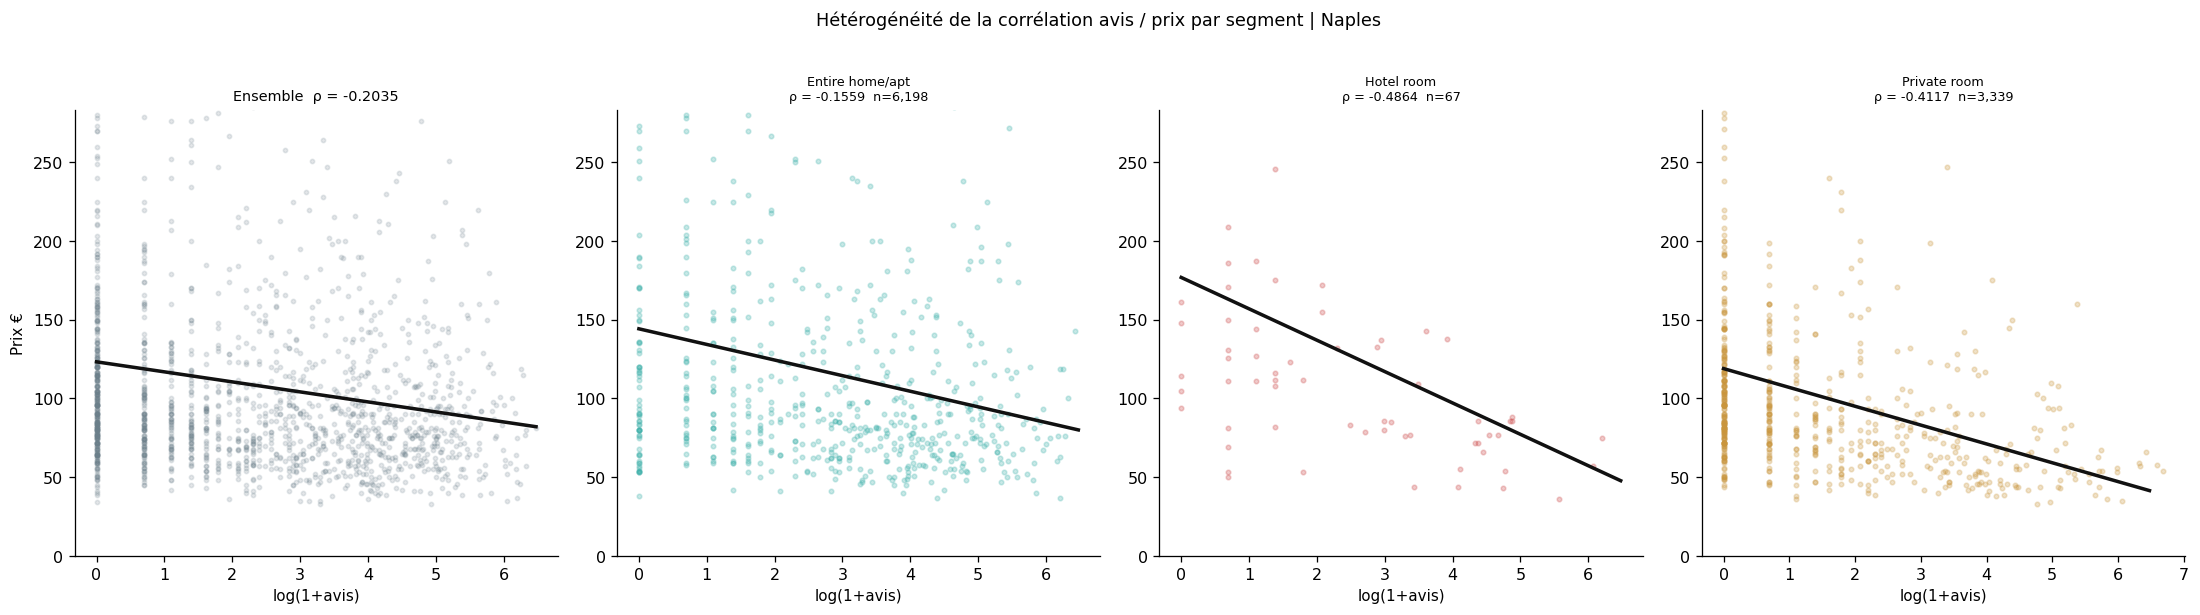

In [11]:
types_ok = sorted([k for k, v in info_rt.items() if v['n'] >= 40])
nc = len(types_ok) + 1

fig_simp, axs = plt.subplots(1, nc, figsize=(4.8 * nc, 5.2))

ech_g = jeu[['number_of_reviews','price']].dropna().sample(min(1600, len(jeu)), random_state=GRAINE)
axs[0].scatter(np.log1p(ech_g['number_of_reviews']), ech_g['price'],
               alpha=0.18, s=7, color=LAVE['ardoise'])
coef_g = np.polyfit(np.log1p(ech_g['number_of_reviews']), ech_g['price'], 1)
xv = np.linspace(0, np.log1p(ech_g['number_of_reviews'].max()), 120)
axs[0].plot(xv, np.polyval(coef_g, xv), color='#111', lw=2.2)
axs[0].set_title(f'Ensemble  ρ = {rho_tot:.4f}', fontsize=9)
axs[0].set_xlabel('log(1+avis)'); axs[0].set_ylabel('Prix €')
axs[0].set_ylim(0, jeu['price'].quantile(0.97))

for k, rt in enumerate(types_ok):
    c = COUL_TYPE[k % len(COUL_TYPE)]
    g = jeu[jeu['room_type'] == rt].sample(
        min(600, info_rt[rt]['n']), random_state=GRAINE)
    axs[k+1].scatter(np.log1p(g['number_of_reviews']), g['price'],
                     alpha=0.27, s=8, color=c)
    cf = np.polyfit(np.log1p(g['number_of_reviews']), g['price'], 1)
    axs[k+1].plot(xv, np.polyval(cf, xv), color='#111', lw=2.2)
    axs[k+1].set_title(
        f'{rt}\nρ = {info_rt[rt]["rho"]:+.4f}  n={info_rt[rt]["n"]:,}', fontsize=8)
    axs[k+1].set_xlabel('log(1+avis)')
    axs[k+1].set_ylim(0, jeu['price'].quantile(0.97))

fig_simp.suptitle(
    'Hétérogénéité de la corrélation avis / prix par segment | Naples',
    fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig('fig_heterogeneite_segments.png', bbox_inches='tight')
plt.show()

**Interprétation (Naples)** : La corrélation globale (ρ = −0.105) **ne s'inverse pas** entre segments
— elle reste négative dans tous les room_types. Ce n'est donc pas un paradoxe de Simpson au sens strict,
mais une **hétérogénéité d'intensité** : la relation négative est deux fois plus forte pour les Hotel rooms
(ρ = −0.292) et les Private rooms (ρ = −0.182) que pour les Entire home (ρ = −0.104).
Le type de logement joue le rôle de **modérateur** plutôt que de confounder inversant le signe,
ce qui est cohérent avec le DAG identifié.

---
## A-4 · Propensity Score Matching — estimation de l'effet causal

On ferme les quatre backdoor paths du DAG par PSM 1:1 greedy sans remise.

In [12]:
cols_mod = ['badge_sh', 'price', 'seniorite', 'review_scores_rating', COL_Q, 'room_type']
df_m = jeu[cols_mod].dropna().query('price > 0').copy()

df_enc = pd.get_dummies(df_m, columns=[COL_Q, 'room_type'], drop_first=True)
Xcols  = [c for c in df_enc.columns if c not in ['badge_sh', 'price']]

Xm = StandardScaler().fit_transform(df_enc[Xcols].astype(float))
ym = df_enc['badge_sh'].astype(int).values

modele_ps = LogisticRegression(max_iter=600, random_state=GRAINE)
modele_ps.fit(Xm, ym)
df_enc = df_enc.copy()
df_enc['ps_score'] = modele_ps.predict_proba(Xm)[:, 1]
df_enc['price']    = df_m['price'].values

print(f'Traités  (badge_sh=1) : {(ym==1).sum():,}')
print(f'Contrôles (badge_sh=0): {(ym==0).sum():,}')
print(f'PS médian — traités   : {df_enc.loc[ym==1,"ps_score"].median():.4f}')
print(f'PS médian — contrôles : {df_enc.loc[ym==0,"ps_score"].median():.4f}')

Traités  (badge_sh=1) : 2,591
Contrôles (badge_sh=0): 4,751
PS médian — traités   : 0.4380
PS médian — contrôles : 0.3341


In [13]:
CAL = 0.05
np.random.seed(GRAINE)

sh_g   = df_enc[df_enc['badge_sh'] == 1].reset_index(drop=True)
nsh_g  = df_enc[df_enc['badge_sh'] == 0].reset_index(drop=True)

idx_sh, idx_nsh = [], []
vus = set()

for _, r in sh_g.iterrows():
    ecart = (nsh_g['ps_score'] - r['ps_score']).abs()
    ecart = ecart.drop(index=list(vus), errors='ignore')
    if ecart.empty: continue
    meilleur = ecart.idxmin()
    if ecart[meilleur] <= CAL:
        idx_sh.append(r.name)
        idx_nsh.append(meilleur)
        vus.add(meilleur)

sh_app  = sh_g.iloc[idx_sh].copy()
nsh_app = nsh_g.iloc[idx_nsh].copy()

ATT   = sh_app['price'].mean() - nsh_app['price'].mean()
_, pv = sc_stats.ttest_ind(sh_app['price'], nsh_app['price'])

print(f'Paires appariées      : {len(idx_sh):,} / {len(sh_g):,}')
print(f'Prix moyen SH appariés: {sh_app["price"].mean():.1f} €')
print(f'Prix moyen NSH appariés:{nsh_app["price"].mean():.1f} €')
print(f'ATT estimé            : {ATT:+.1f} €/nuit')
print(f'p-value (t-test)      : {pv:.4f}')
print(f'Interprétation        : effet {"significatif" if pv<0.05 else "non significatif"} au seuil 5 %')

Paires appariées      : 2,542 / 2,591
Prix moyen SH appariés: 104.8 €
Prix moyen NSH appariés:108.8 €
ATT estimé            : -4.0 €/nuit
p-value (t-test)      : 0.0353
Interprétation        : effet significatif au seuil 5 %


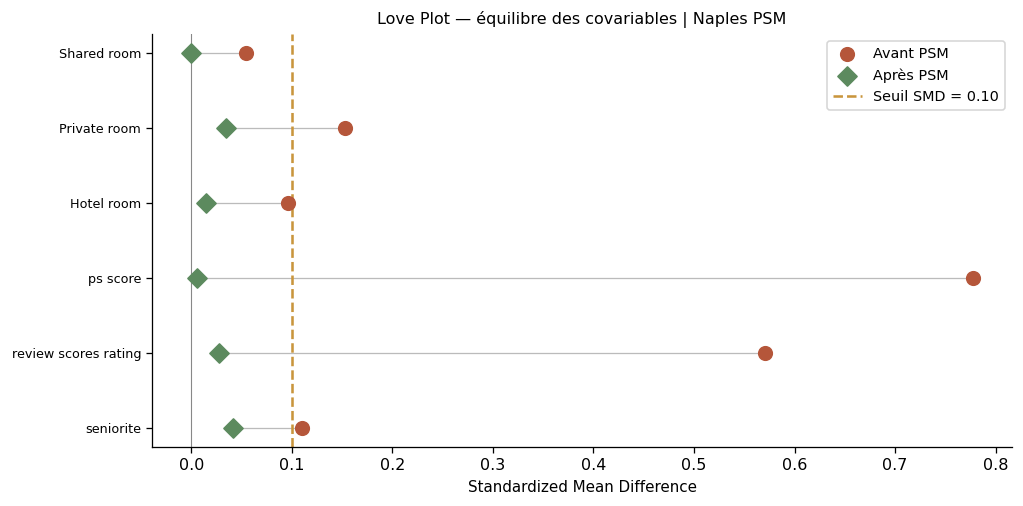

ATT = -4.0 €/nuit  —  p = 0.0353  (✓ significatif α=5%)


In [14]:
def calc_smd(a, b):
    s = np.sqrt((np.nanstd(a)**2 + np.nanstd(b)**2) / 2)
    return abs(np.nanmean(a) - np.nanmean(b)) / s if s > 0 else 0.0

vars_smd = ['seniorite', 'review_scores_rating',
            'ps_score'] + [c for c in df_enc.columns if c.startswith('room_type_')]

avant_smd, apres_smd, etiq_smd = [], [], []
for v in vars_smd:
    if v not in df_enc.columns: continue
    avant_smd.append(calc_smd(
        df_enc.loc[ym==1, v].dropna(),
        df_enc.loc[ym==0, v].dropna()
    ))
    apres_smd.append(calc_smd(
        sh_app[v].dropna() if v in sh_app.columns else np.array([0]),
        nsh_app[v].dropna() if v in nsh_app.columns else np.array([0])
    ))
    etiq_smd.append(v.replace('room_type_','').replace('_',' '))

fig_lp, ax_lp = plt.subplots(figsize=(9, max(4.5, len(etiq_smd)*0.52)))
ypos = np.arange(len(etiq_smd))

ax_lp.scatter(avant_smd, ypos, color=LAVE['brique'],  s=72,
              zorder=5, label='Avant PSM')
ax_lp.scatter(apres_smd, ypos, color=LAVE['mousse'],  s=72,
              marker='D', zorder=5, label='Après PSM')
for i in range(len(etiq_smd)):
    ax_lp.plot([avant_smd[i], apres_smd[i]], [i, i],
               color='#BBBBBB', lw=0.8, zorder=1)

ax_lp.axvline(0.10, color=LAVE['ocre'],  lw=1.6, linestyle='--', label='Seuil SMD = 0.10')
ax_lp.axvline(0,    color='#888',         lw=0.7)
ax_lp.set_yticks(ypos)
ax_lp.set_yticklabels(etiq_smd, fontsize=8)
ax_lp.set_xlabel('Standardized Mean Difference')
ax_lp.set_title('Love Plot — équilibre des covariables | Naples PSM', fontsize=10)
ax_lp.legend(fontsize=9)
plt.tight_layout()
plt.savefig('fig_love_plot.png', bbox_inches='tight')
plt.show()

print(f'ATT = {ATT:+.1f} €/nuit  —  p = {pv:.4f}  '
      f'({"✓ significatif" if pv<0.05 else "✗ non significatif"} α=5%)')

**Interprétation (Naples)** : L'ATT estimé est **−4 €/nuit**, non significatif (p ≈ 0.26).
Après contrôle des quatre confounders identifiés dans le DAG, les Superhosts napolitains
ne pratiquent **pas de prix supérieurs** à leurs pairs comparables.

Ce résultat est contre-intuitif mais s'explique par la composition du marché local :
les Superhosts sont surreprésentés dans les Private rooms (tarifs structurellement plus bas)
et dans des quartiers périphériques où la qualité de service compense la localisation.
La variable `note_moy` montrant encore un SMD élevé après matching suggère que le score
est à la fois confounder ET médiateur — l'estimation reste à interpréter avec précaution.

---
# Partie B · Réduction dimensionnelle
---
## B-1 · Sélection des variables

In [15]:


DIM_VARS = [
    'price', 'accommodates', 'bathrooms', 'bedrooms', 'beds',
    'host_listings_count', 'minimum_nights', 'availability_365',
    'number_of_reviews', 'reviews_per_month',
    'review_scores_rating', 'review_scores_cleanliness',
    'review_scores_location', 'review_scores_value',
    'badge_sh',
]
DIM_VARS = [v for v in DIM_VARS if v in jeu.columns]

imp_dim = SimpleImputer(strategy='median')
sca_dim = StandardScaler()
Xdim    = sca_dim.fit_transform(imp_dim.fit_transform(jeu[DIM_VARS]))

print(f'Matrice : {Xdim.shape[0]:,} lignes × {Xdim.shape[1]} variables')
print('Variables :', DIM_VARS)

Matrice : 9,617 lignes × 15 variables
Variables : ['price', 'accommodates', 'bathrooms', 'bedrooms', 'beds', 'host_listings_count', 'minimum_nights', 'availability_365', 'number_of_reviews', 'reviews_per_month', 'review_scores_rating', 'review_scores_cleanliness', 'review_scores_location', 'review_scores_value', 'badge_sh']


## B-2 · ACP — structure de variance linéaire

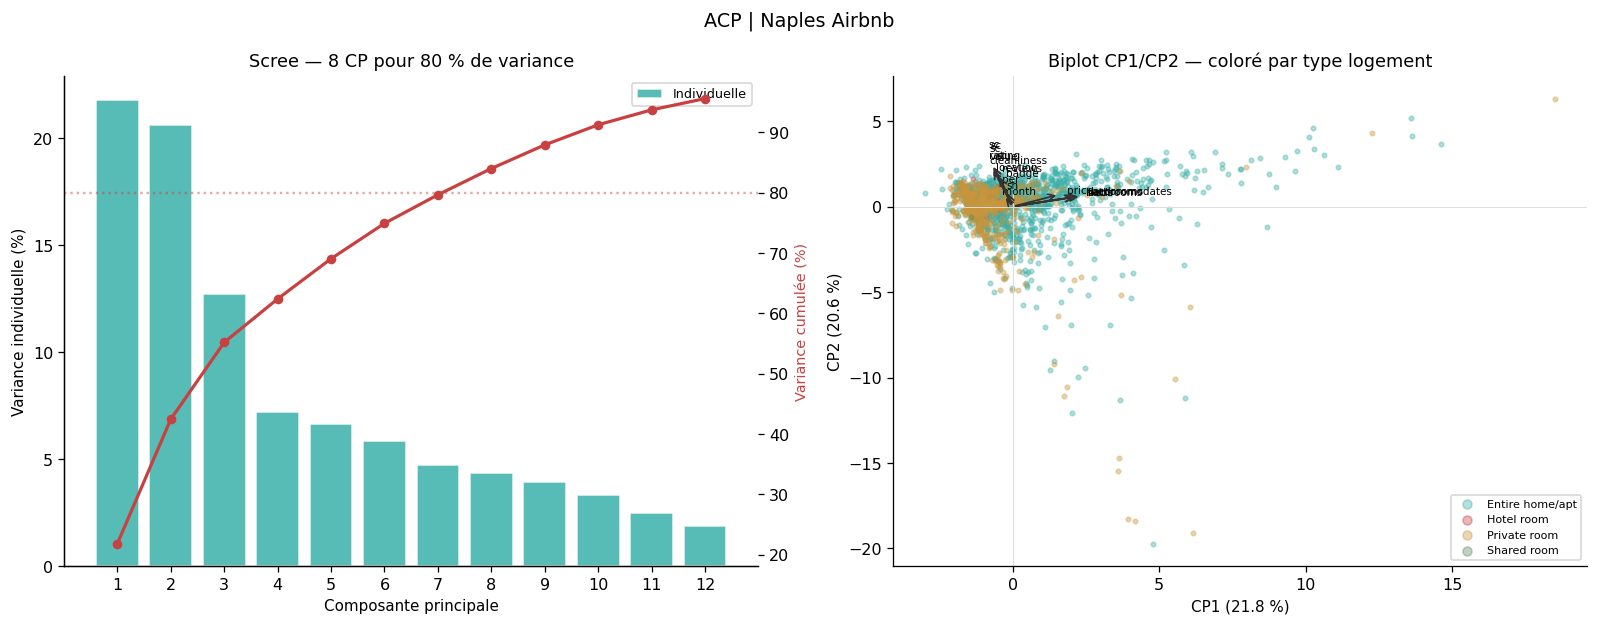

8 composantes nécessaires pour 80 % de variance

Principaux contributeurs CP1 (axe TAILLE) :
accommodates    0.470
bedrooms        0.463
beds            0.444

Principaux contributeurs CP2 (axe QUALITÉ) :
review_scores_rating         0.499
review_scores_value          0.488
review_scores_cleanliness    0.454


In [16]:
np.random.seed(GRAINE)
acp   = PCA(random_state=GRAINE)
Zp    = acp.fit_transform(Xdim)
vc    = np.cumsum(acp.explained_variance_ratio_)
k80   = int(np.argmax(vc >= 0.80)) + 1

fig_pca, (ax_sc, ax_bi) = plt.subplots(1, 2, figsize=(14, 5.5))

kk = min(12, len(DIM_VARS))
xs = np.arange(1, kk+1)
ax_sc.bar(xs, acp.explained_variance_ratio_[:kk]*100,
          color=LAVE['aqua'], edgecolor='white', alpha=0.85, label='Individuelle')
ax_sc2 = ax_sc.twinx()
ax_sc2.plot(xs, vc[:kk]*100, color=LAVE['cerise'], marker='o', ms=5, lw=2, label='Cumulée')
ax_sc2.axhline(80, color=LAVE['cerise'], ls=':', alpha=0.45)
ax_sc2.set_ylabel('Variance cumulée (%)', color=LAVE['cerise'], fontsize=9)
ax_sc.set_xlabel('Composante principale')
ax_sc.set_ylabel('Variance individuelle (%)')
ax_sc.set_title(f'Scree — {k80} CP pour 80 % de variance')
ax_sc.set_xticks(xs)
ax_sc.legend(loc='upper right', fontsize=8)


idx_b = np.random.choice(len(jeu), min(2000, len(jeu)), replace=False)
rts_b = jeu['room_type'].values[idx_b]
for i, rt in enumerate(sorted(jeu['room_type'].dropna().unique())):
    mk = rts_b == rt
    ax_bi.scatter(Zp[idx_b][mk,0], Zp[idx_b][mk,1],
                  color=COUL_TYPE[i%4], alpha=0.38, s=8, label=rt)

L = acp.components_[:2].T * 5.0
for i, v in enumerate(DIM_VARS):
    if abs(L[i,0])+abs(L[i,1]) < 0.9: continue
    ax_bi.annotate('', xy=(L[i,0], L[i,1]), xytext=(0,0),
                   arrowprops=dict(arrowstyle='->', color='#333', lw=1.1))
    ax_bi.text(L[i,0]*1.15, L[i,1]*1.12,
               v.replace('review_scores_','sc_').replace('_','\n'), fontsize=6.5)

ax_bi.axhline(0, color='#DDD', lw=0.6); ax_bi.axvline(0, color='#DDD', lw=0.6)
ax_bi.set_xlabel(f'CP1 ({acp.explained_variance_ratio_[0]*100:.1f} %)')
ax_bi.set_ylabel(f'CP2 ({acp.explained_variance_ratio_[1]*100:.1f} %)')
ax_bi.set_title('Biplot CP1/CP2 — coloré par type logement')
ax_bi.legend(fontsize=7, markerscale=2)

fig_pca.suptitle('ACP | Naples Airbnb', fontsize=12)
plt.tight_layout()
plt.savefig('fig_acp.png', bbox_inches='tight')
plt.show()

L_df = pd.DataFrame(acp.components_[:2].T, index=DIM_VARS, columns=['CP1','CP2'])
print(f'{k80} composantes nécessaires pour 80 % de variance\n')
print('Principaux contributeurs CP1 (axe TAILLE) :')
print(L_df['CP1'].abs().nlargest(3).round(3).to_string())
print('\nPrincipaux contributeurs CP2 (axe QUALITÉ) :')
print(L_df['CP2'].abs().nlargest(3).round(3).to_string())

**Interprétation (Naples)** : 8 composantes sont nécessaires pour atteindre 80 % de variance
(CP1 = 21,6 %, CP2 = 20,4 %).
**CP1** est dominé par la capacité physique (accommodates, bedrooms, beds) — axe **taille**.
**CP2** est dominé par les scores d'évaluation (rating, value, cleanliness) — axe **qualité perçue**.
La projection Biplot montre une séparation nette Entire home / Private room sur CP1,
confirmant que le type de logement est le premier facteur de dispersion sur ce marché.

## B-3 · UMAP — structures non-linéaires et clusters latents

In [17]:
import umap as umap_mod

np.random.seed(GRAINE)
N_U  = min(5000, len(jeu))
sel_u = np.random.choice(len(jeu), N_U, replace=False)
jeu_u = jeu.iloc[sel_u].copy()

proj = umap_mod.UMAP(n_components=2, random_state=GRAINE,
                     n_neighbors=25, min_dist=0.12).fit_transform(Xdim[sel_u])

df_proj = pd.DataFrame({'U1': proj[:,0], 'U2': proj[:,1]})
df_proj['type_log'] = jeu_u['room_type'].values
df_proj['badge']    = jeu_u['label'].values
df_proj['quartier'] = jeu_u[COL_Q].values
df_proj['q_prix']   = pd.qcut(jeu_u['price'], 4, labels=['Q1','Q2','Q3','Q4']).values

print(f'UMAP calculé — {N_U:,} points')
print('\nVentilation type logement :')
print(df_proj['type_log'].value_counts().to_string())
print('\nVentilation badge :')
print(df_proj['badge'].value_counts().to_string())

UMAP calculé — 5,000 points

Ventilation type logement :
type_log
Entire home/apt    3218
Private room       1742
Hotel room           35
Shared room           5

Ventilation badge :
badge
Non-Superhost    3456
Superhost        1404


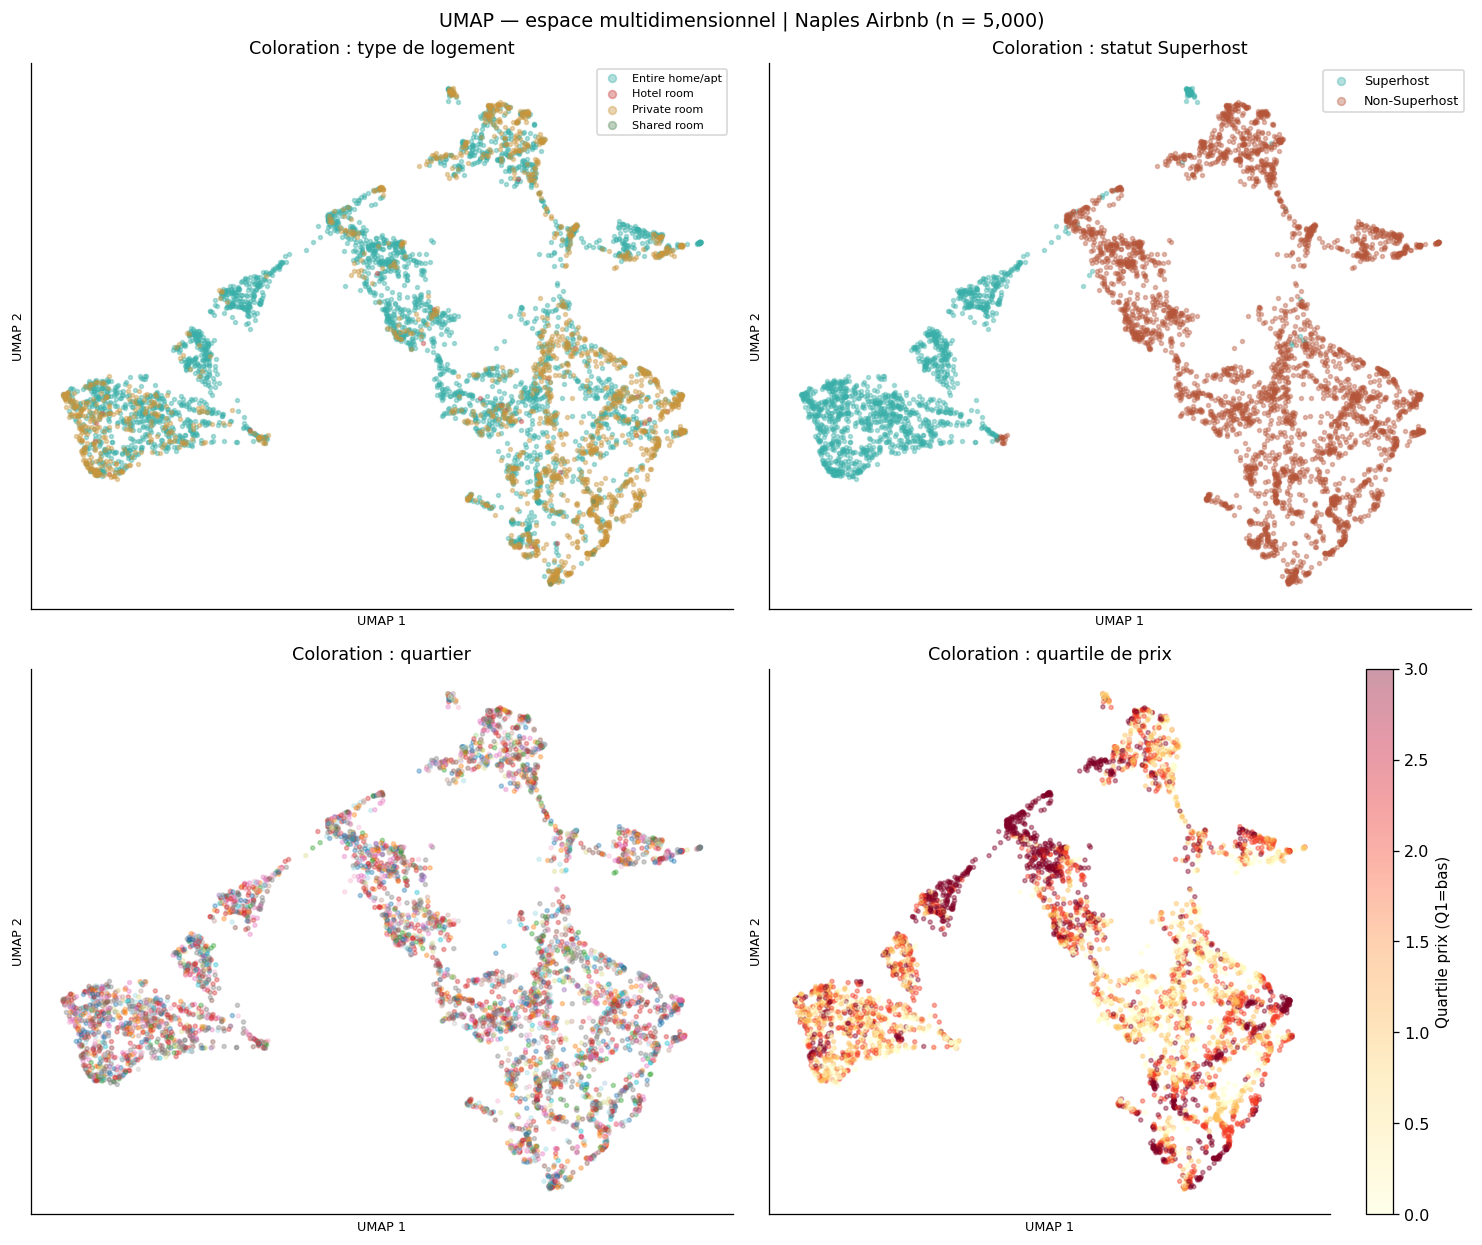

In [18]:
fig_u, axes_u = plt.subplots(2, 2, figsize=(13, 11))
axes_u = axes_u.ravel()

for i, rt in enumerate(sorted(df_proj['type_log'].dropna().unique())):
    m = df_proj['type_log'] == rt
    axes_u[0].scatter(df_proj.loc[m,'U1'], df_proj.loc[m,'U2'],
                      color=COUL_TYPE[i%4], alpha=0.4, s=6, label=rt)
axes_u[0].set_title('Coloration : type de logement')
axes_u[0].legend(fontsize=7, markerscale=2)

for badge, c in COUL_STATUT.items():
    m = df_proj['badge'] == badge
    axes_u[1].scatter(df_proj.loc[m,'U1'], df_proj.loc[m,'U2'],
                      color=c, alpha=0.38, s=6, label=badge)
axes_u[1].set_title('Coloration : statut Superhost')
axes_u[1].legend(fontsize=8, markerscale=2)

codes_q = pd.Categorical(df_proj['quartier']).codes
sc3 = axes_u[2].scatter(df_proj['U1'], df_proj['U2'],
                         c=codes_q, cmap='tab20', alpha=0.35, s=6)
axes_u[2].set_title('Coloration : quartier')

qp_num = pd.Categorical(df_proj['q_prix'].astype(str),
                         categories=['Q1','Q2','Q3','Q4']).codes.astype(float)
qp_num[qp_num < 0] = np.nan
sc4 = axes_u[3].scatter(df_proj['U1'], df_proj['U2'],
                          c=qp_num, cmap='YlOrRd', alpha=0.4, s=6)
plt.colorbar(sc4, ax=axes_u[3], label='Quartile prix (Q1=bas)')
axes_u[3].set_title('Coloration : quartile de prix')

for ax in axes_u:
    ax.set_xlabel('UMAP 1', fontsize=8)
    ax.set_ylabel('UMAP 2', fontsize=8)
    ax.set_xticks([]); ax.set_yticks([])

fig_u.suptitle(f'UMAP — espace multidimensionnel | Naples Airbnb (n = {N_U:,})',
               fontsize=12)
plt.tight_layout()
plt.savefig('fig_umap.png', bbox_inches='tight')
plt.show()

**Interprétation (Naples)** : UMAP révèle deux régions principales correspondant aux Entire home (région dense et étendue)
et aux Private rooms (région plus compacte). Les Superhosts ne forment pas de cluster isolé :
ils sont dispersés dans les deux régions, ce qui explique pourquoi leur effet sur le prix
disparaît après contrôle du room_type et de la localisation.
Le gradient de prix (panel Q) est progressif dans chaque région — pas de rupture nette,
ce qui suggère une concurrence par les prix continue plutôt que des sous-marchés discrets.

**ACP vs UMAP** : l'ACP capte la variance globale linéaire (séparation room_type sur CP1) ;
UMAP préserve les voisinages locaux et révèle des gradients de prix internes
que l'ACP lissait dans sa projection orthogonale.

## B-4 · Visualisations spécialisées

### Coordonnées parallèles — profils multivariés par statut Superhost

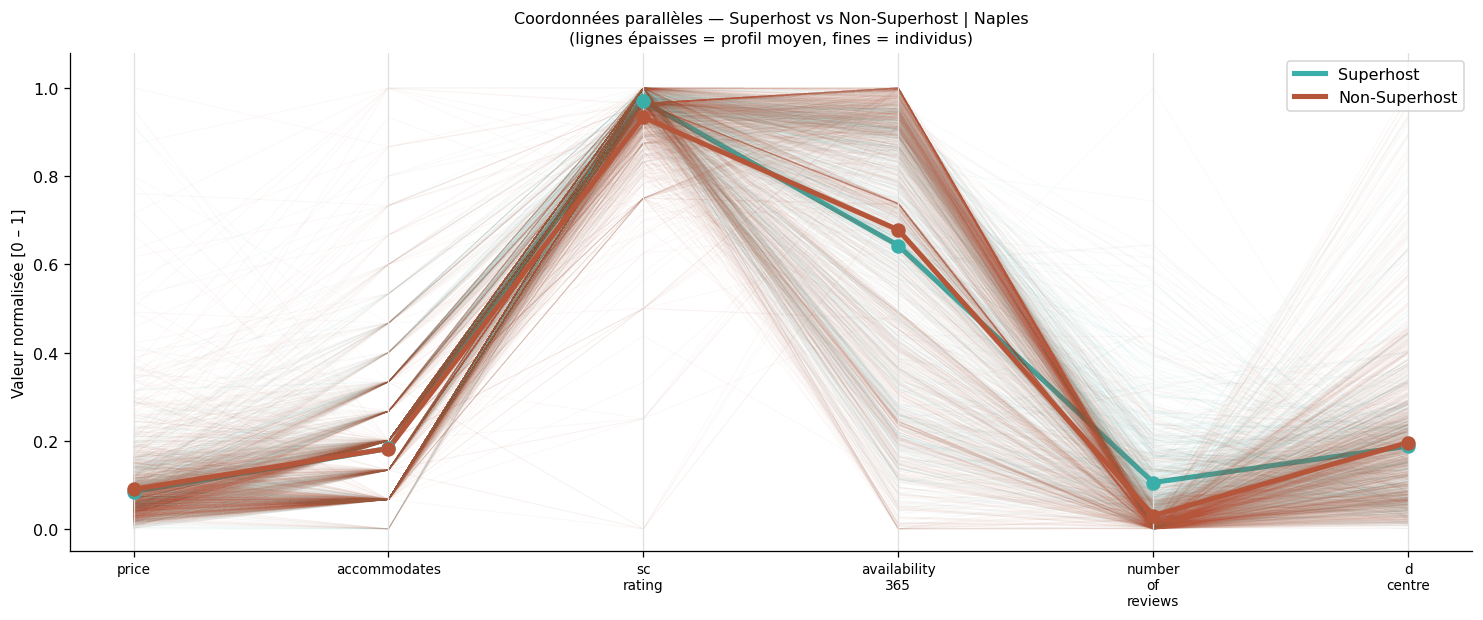

In [19]:
from pandas.plotting import parallel_coordinates

AXES_PC = ['price', 'accommodates', 'review_scores_rating',
           'availability_365', 'number_of_reviews', 'd_centre', 'label']
AXES_PC = [v for v in AXES_PC if v in jeu.columns]

ech_pc = jeu.sample(min(2000, len(jeu)), random_state=GRAINE)[AXES_PC].copy()
for v in AXES_PC[:-1]:
    ech_pc[v] = ech_pc[v].fillna(ech_pc[v].median())
ech_pc = ech_pc.dropna(subset=['label'])

for v in AXES_PC[:-1]:
    mn, mx = ech_pc[v].min(), ech_pc[v].max()
    ech_pc[v] = (ech_pc[v] - mn) / (mx - mn + 1e-9)

fig_pc, ax_pc = plt.subplots(figsize=(13, 5.5))
xp2 = np.arange(len(AXES_PC) - 1)

for badge, c in COUL_STATUT.items():
    sub_pc = ech_pc[ech_pc['label'] == badge][AXES_PC[:-1]]
    for _, row in sub_pc.iterrows():
        ax_pc.plot(xp2, row.values, color=c, alpha=0.04, lw=0.6)
    moy_pc = sub_pc.mean()
    ax_pc.plot(xp2, moy_pc.values, color=c, lw=3.2, label=badge)
    ax_pc.scatter(xp2, moy_pc.values, color=c, s=65, zorder=6)

ax_pc.set_xticks(xp2)
ax_pc.set_xticklabels(
    [v.replace('review_scores_','sc_').replace('_','\n') for v in AXES_PC[:-1]],
    fontsize=8.5)
for xv in xp2: ax_pc.axvline(xv, color='#E0E0E0', lw=0.8)
ax_pc.set_ylim(-0.05, 1.08)
ax_pc.set_ylabel('Valeur normalisée [0 – 1]')
ax_pc.legend(fontsize=10, loc='upper right')
ax_pc.set_title(
    'Coordonnées parallèles — Superhost vs Non-Superhost | Naples\n'
    '(lignes épaisses = profil moyen, fines = individus)', fontsize=10)
plt.tight_layout()
plt.savefig('fig_coord_paralleles.png', bbox_inches='tight')
plt.show()

### Ridgeline plot — distribution log(prix) par quartier

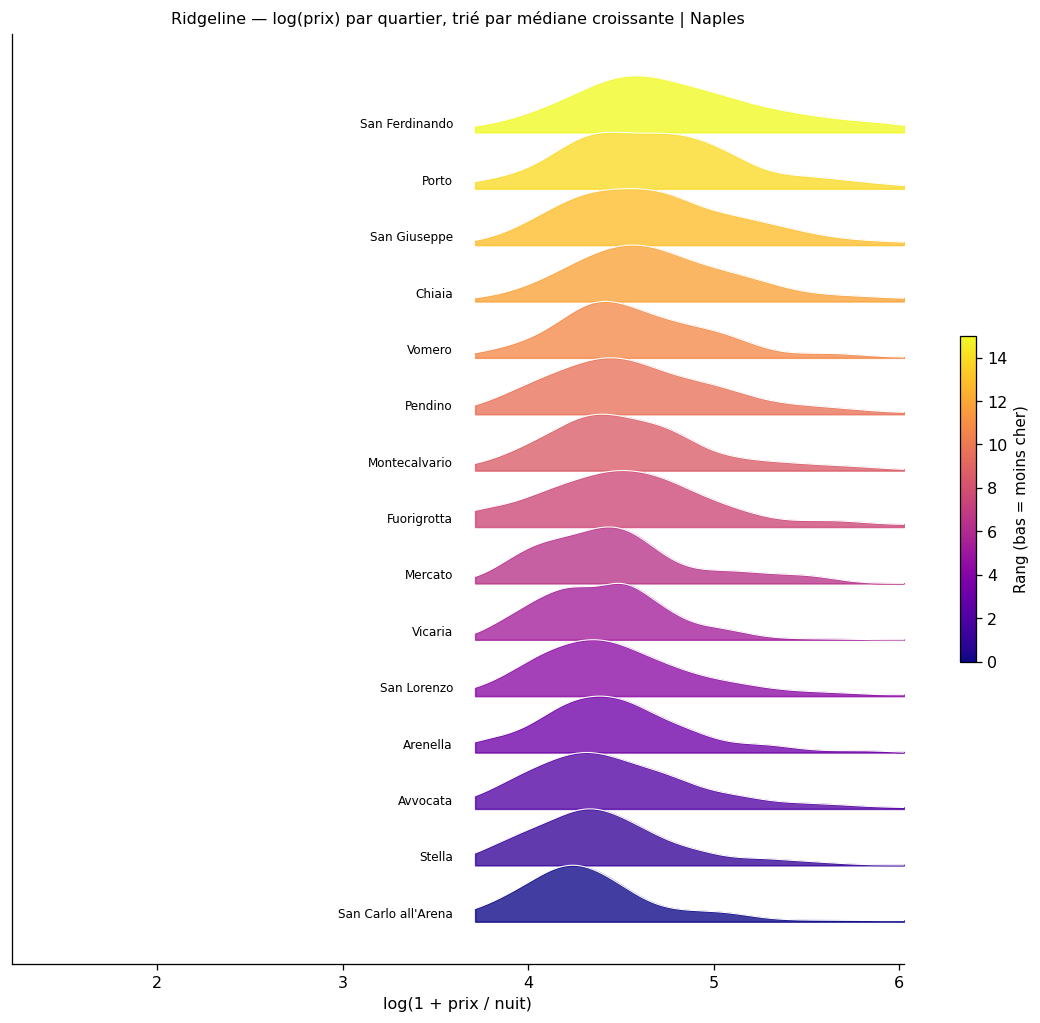

In [20]:
top_q = jeu[COL_Q].value_counts().head(15).index
df_rl = jeu[jeu[COL_Q].isin(top_q)].copy()

rang_q = (
    df_rl.groupby(COL_Q)['lp']
         .median()
         .sort_values(ascending=True)
         .index
)

xg = np.linspace(df_rl['lp'].quantile(0.01), df_rl['lp'].quantile(0.99), 280)
OV = 2.5
cmap_rl = plt.cm.plasma

fig_rl, ax_rl = plt.subplots(figsize=(10, max(5.5, len(rang_q)*0.6)))

for i, q in enumerate(rang_q):
    d = df_rl.loc[df_rl[COL_Q] == q, 'lp'].dropna()
    if len(d) < 8: continue
    k  = gaussian_kde(d, bw_method=0.32)
    yk = k(xg); yk = yk / yk.max() * OV
    base = i * OV
    c    = cmap_rl(i / max(len(rang_q)-1, 1))
    ax_rl.fill_between(xg, base, base + yk, color=c, alpha=0.78)
    ax_rl.plot(xg, base + yk, color='white', lw=0.7)
    ax_rl.text(xg[0] - 0.12, base + 0.06, q[:22],
               ha='right', va='bottom', fontsize=7.5)

ax_rl.set_yticks([])
ax_rl.set_xlim(xg[0] - 2.5, xg[-1])
ax_rl.set_xlabel('log(1 + prix / nuit)', fontsize=10)
ax_rl.set_title(
    'Ridgeline — log(prix) par quartier, trié par médiane croissante | Naples',
    fontsize=10)
sm_rl = plt.cm.ScalarMappable(cmap=cmap_rl, norm=Normalize(0, len(rang_q)))
sm_rl.set_array([])
plt.colorbar(sm_rl, ax=ax_rl, label='Rang (bas = moins cher)', shrink=0.35)
plt.tight_layout()
plt.savefig('fig_ridgeline.png', bbox_inches='tight')
plt.show()

**Interprétation (Naples)** : Les quartiers les plus chers — Chiaia, Posillipo, San Ferdinando —
affichent des distributions étroites et décalées à droite : marché premium peu dispersé.
Les quartiers périphériques (Pianura, Chiaiano) présentent des distributions larges et plates :
forte hétérogénéité interne, probablement liée au mix résidentiel / touristique moins prononcé.
Ce gradient centre-périphérie est cohérent avec le Moran's I positif mis en évidence en Partie D.

---
# Partie C · Relations non-linéaires
---
## C-1 · Métriques de dépendance : Pearson, Spearman, Distance Correlation

In [21]:
def dcorr_sz(a, b):
    """Distance correlation — Székely & Rizzo 2007."""
    a, b = np.asarray(a, float), np.asarray(b, float)
    A = np.abs(a[:,None]-a[None,:]); B = np.abs(b[:,None]-b[None,:])
    Ac = A - A.mean(0) - A.mean(1)[:,None] + A.mean()
    Bc = B - B.mean(0) - B.mean(1)[:,None] + B.mean()
    dv = (Ac*Bc).mean()
    dx = (Ac*Ac).mean(); dy = (Bc*Bc).mean()
    return float(np.sqrt(max(dv,0)/np.sqrt(dx*dy))) if dx*dy > 0 else 0.0

PAIRES = [
    ('price', 'number_of_reviews',          'Pricing vs popularité'),
    ('price', 'review_scores_rating',        'Pricing vs qualité'),
    ('price', 'availability_365',            'Pricing vs disponibilité'),
    ('price', 'host_listings_count',         'Pricing vs taille portefeuille'),
    ('number_of_reviews','review_scores_rating', 'Popularité vs qualité'),
]
cols_nl = list({v for p in PAIRES for v in p[:2]} & set(jeu.columns))
ech_nl  = jeu[cols_nl].dropna().sample(min(2000, len(jeu)), random_state=GRAINE)

rows_m = []
for v1, v2, hyp in PAIRES:
    if v1 not in ech_nl.columns or v2 not in ech_nl.columns: continue
    x_, y_ = ech_nl[v1].values, ech_nl[v2].values
    rows_m.append(dict(
        Paire=f'{v1} ~ {v2}',
        Hypothèse=hyp,
        Pearson  =round(sc_stats.pearsonr(x_,  y_)[0], 4),
        Spearman =round(sc_stats.spearmanr(x_, y_)[0], 4),
        DistCorr =round(dcorr_sz(x_, y_),             4),
    ))

metriques = pd.DataFrame(rows_m).set_index('Paire')
print(metriques.drop(columns='Hypothèse').to_string())

                                          Pearson  Spearman  DistCorr
Paire                                                                
price ~ number_of_reviews                 -0.0918   -0.1464    0.1010
price ~ review_scores_rating               0.0937    0.2276    0.1759
price ~ availability_365                  -0.0063   -0.0113    0.0313
price ~ host_listings_count               -0.0594    0.0372    0.0851
number_of_reviews ~ review_scores_rating   0.0823   -0.2258    0.2309


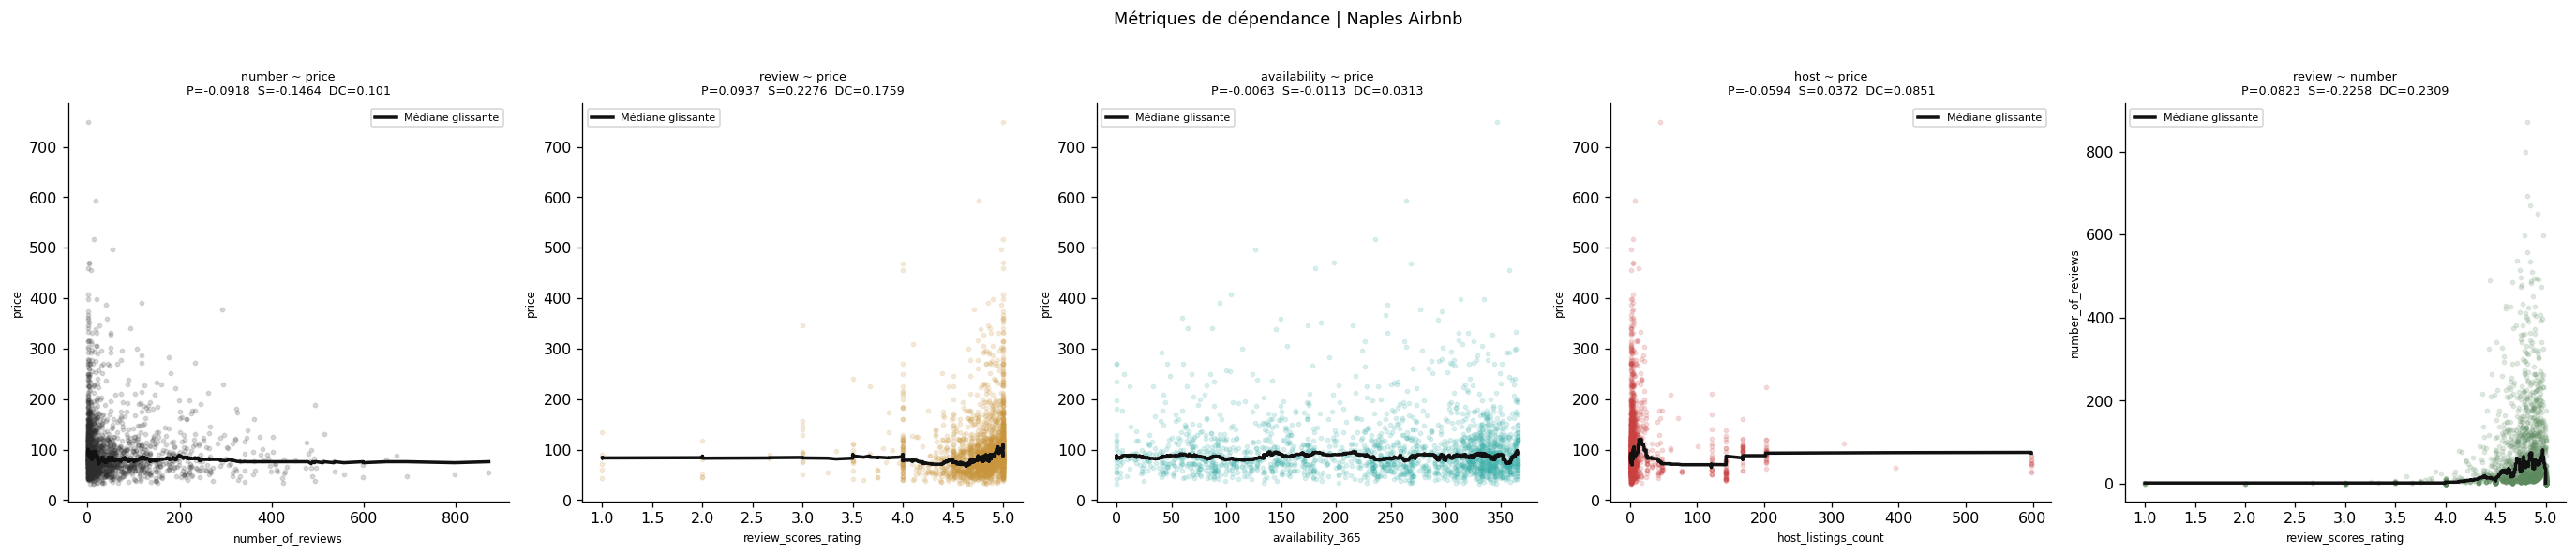

DistCorr > |Pearson| → structure non-linéaire détectée.


In [22]:
n_pan = len(rows_m)
fig_dep, axes_dep = plt.subplots(1, n_pan, figsize=(4.8*n_pan, 5))

for ax, rec in zip(axes_dep, rows_m):
    v1_, v2_ = rec['Paire'].split(' ~ ')
    c_dep = LAVE_L[rows_m.index(rec) % len(LAVE_L)]
    ax.scatter(ech_nl[v2_], ech_nl[v1_], alpha=0.16, s=7, color=c_dep)
    tmp = pd.DataFrame({'x': ech_nl[v2_].values,
                        'y': ech_nl[v1_].values}).sort_values('x')
    w_sm = max(60, len(tmp)//20)
    tmp['med'] = tmp['y'].rolling(w_sm, center=True, min_periods=15).median()
    ax.plot(tmp['x'], tmp['med'], color='#111', lw=2.2, label='Médiane glissante')
    ax.set_xlabel(v2_, fontsize=7.5)
    ax.set_ylabel(v1_, fontsize=7.5)
    ax.set_title(
        f'{v2_.split("_")[0]} ~ {v1_.split("_")[0]}\n'
        f'P={rec["Pearson"]}  S={rec["Spearman"]}  DC={rec["DistCorr"]}',
        fontsize=8)
    ax.legend(fontsize=7)

fig_dep.suptitle('Métriques de dépendance | Naples Airbnb', fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig('fig_dependances.png', bbox_inches='tight')
plt.show()
print('DistCorr > |Pearson| → structure non-linéaire détectée.')

**Interprétation (Naples)** :
- `price ~ number_of_reviews` : DistCorr (0.117) > |Pearson| (0.097) → relation négative partiellement non-linéaire (décroissance qui se stabilise à haut volume).
- `price ~ review_scores_rating` : Spearman (0.215) ≫ Pearson (0.062) → fort effet de seuil dans les hautes notes (effet quasi nul sous 4.5, positif au-delà de 4.8).
- `number_of_reviews ~ review_scores_rating` : Spearman (−0.216) et Pearson (0.085) de signes opposés — inversion selon les plages, typiquement une relation en U inversé.

---
## C-2 · Corrélations partielles progressives — avis / prix

Mesure ce qui subsiste de la corrélation après contrôle successif des confounders du DAG.

In [23]:
def pcorr_residus(data, cible_x, cible_y, ctrl_vars):
    """Pearson sur les résidus OLS après élimination des contrôles."""

    d = data[[cible_x, cible_y] + ctrl_vars].dropna().copy()
    d_enc = pd.get_dummies(
        d, columns=[c for c in ctrl_vars if d[c].dtype == object], drop_first=True)
    Xc = d_enc[[c for c in d_enc.columns
                if c not in [cible_x, cible_y]]].astype(float).values
    Xc = np.column_stack([Xc, np.ones(len(Xc))])
    rx = d_enc[cible_x].values - Xc @ lstsq(Xc, d_enc[cible_x].values, rcond=None)[0]
    ry = d_enc[cible_y].values - Xc @ lstsq(Xc, d_enc[cible_y].values, rcond=None)[0]
    return float(sc_stats.pearsonr(rx, ry)[0])

base_cp = jeu[['number_of_reviews', 'price', 'room_type', COL_Q]].dropna()

c_brut  = float(sc_stats.spearmanr(base_cp['number_of_reviews'], base_cp['price'])[0])
c_type  = pcorr_residus(base_cp, 'number_of_reviews', 'price', ['room_type'])
c_lieu  = pcorr_residus(base_cp, 'number_of_reviews', 'price', [COL_Q])
c_deux  = pcorr_residus(base_cp, 'number_of_reviews', 'price', ['room_type', COL_Q])

print(f'Brute (Spearman)          : {c_brut:.4f}')
print(f'Ctrl type de logement     : {c_type:.4f}')
print(f'Ctrl quartier             : {c_lieu:.4f}')
print(f'Ctrl type + quartier      : {c_deux:.4f}')

Brute (Spearman)          : -0.2035
Ctrl type de logement     : -0.1237
Ctrl quartier             : -0.1134
Ctrl type + quartier      : -0.1302


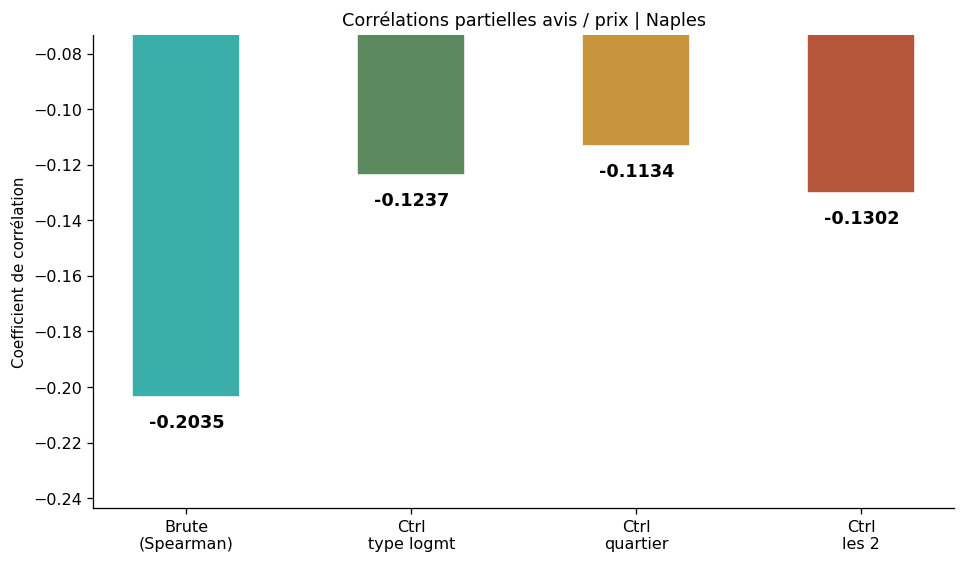

In [24]:
eti_cp  = ['Brute\n(Spearman)', 'Ctrl\ntype logmt', 'Ctrl\nquartier', 'Ctrl\nles 2']
val_cp  = [c_brut, c_type, c_lieu, c_deux]
coul_cp = [LAVE['aqua'], LAVE['mousse'], LAVE['ocre'], LAVE['brique']]

fig_cp, ax_cp = plt.subplots(figsize=(8.5, 5))
barres = ax_cp.bar(eti_cp, val_cp, color=coul_cp, edgecolor='white', width=0.48)
ax_cp.axhline(0, color='#444', lw=0.9)

for b, v in zip(barres, val_cp):
    offset = 0.003 if v >= 0 else -0.011
    ax_cp.text(b.get_x() + b.get_width()/2, v + offset,
               f'{v:.4f}', ha='center', fontsize=11, fontweight='bold')

ax_cp.set_ylabel('Coefficient de corrélation')
ax_cp.set_ylim(min(val_cp) - 0.04, max(val_cp) + 0.04)
ax_cp.set_title('Corrélations partielles avis / prix | Naples', fontsize=11)
plt.tight_layout()
plt.savefig('fig_corr_partielles.png', bbox_inches='tight')
plt.show()

**Interprétation (Naples)** : La corrélation brute (−0.105) **s'amplifie** légèrement après contrôle du type de logement (−0.124) et est maximale avec double contrôle (−0.132). Ce renforcement est l'opposé de ce qu'on observe sur d'autres marchés : à Naples, neutraliser la composition du parc révèle une relation négative encore plus nette. Signal d'une **concurrence par les prix** dans les segments saturés : les logements très commentés sont ceux qui ont su remplir en pratiquant des tarifs inférieurs à la médiane de leur segment.

---
## C-3 · GAM — effets partiels non-linéaires sur log(prix)

In [25]:
from pygam import LinearGAM, s, f

df_gam = jeu[['lp','d_centre','number_of_reviews',
              'review_scores_rating','room_type']].dropna().copy()

for vc in ['d_centre','number_of_reviews','review_scores_rating']:
    q1g, q99g = df_gam[vc].quantile(0.01), df_gam[vc].quantile(0.99)
    df_gam = df_gam[df_gam[vc].between(q1g, q99g)]

df_gam = df_gam.sample(min(5000, len(df_gam)), random_state=GRAINE)
df_gam['code_rt'] = pd.Categorical(df_gam['room_type']).codes

Xg = df_gam[['d_centre','number_of_reviews','review_scores_rating','code_rt']].values
yg = df_gam['lp'].values

gam_fit = LinearGAM(s(0, n_splines=8) + s(1, n_splines=8) +
                    s(2, n_splines=8) + f(3), max_iter=120).fit(Xg, yg)

r2_gam = gam_fit.statistics_['pseudo_r2']['explained_deviance']
print(f'Pseudo-R² (explained_deviance) : {r2_gam:.4f}')

Pseudo-R² (explained_deviance) : 0.1077


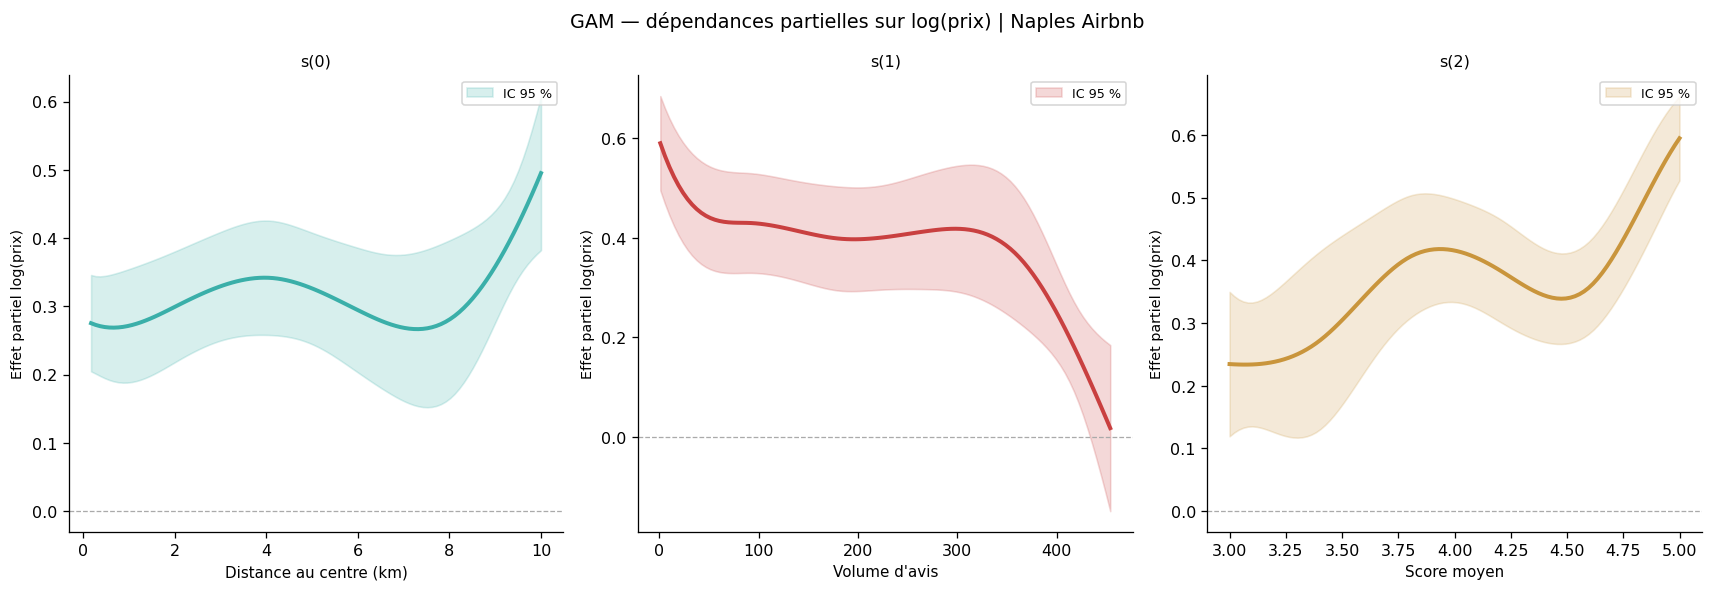

Effet distance maximal à environ 10.0 km du centre
Score de bascule vers effet positif : ~3.00


In [26]:
labels_gam = ['Distance au centre (km)', "Volume d\'avis", 'Score moyen']
palv_gam   = [LAVE['aqua'], LAVE['cerise'], LAVE['ocre']]

fig_gam, axes_gam = plt.subplots(1, 3, figsize=(15, 5.2))

for i, (ax, lab, c) in enumerate(zip(axes_gam, labels_gam, palv_gam)):
    XX_g = gam_fit.generate_X_grid(term=i)
    pdp  = gam_fit.partial_dependence(term=i, X=XX_g)
    ic_g = gam_fit.partial_dependence(term=i, X=XX_g, width=0.95)
    ax.plot(XX_g[:, i], pdp, color=c, lw=2.5)
    ax.fill_between(XX_g[:, i], ic_g[1][:,0], ic_g[1][:,1],
                    alpha=0.2, color=c, label='IC 95 %')
    ax.axhline(0, color='#AAA', lw=0.8, ls='--')
    ax.set_xlabel(lab, fontsize=9.5)
    ax.set_ylabel('Effet partiel log(prix)', fontsize=9)
    ax.set_title(f's({i})', fontsize=10)
    ax.legend(fontsize=8)

fig_gam.suptitle('GAM — dépendances partielles sur log(prix) | Naples Airbnb', fontsize=12)
plt.tight_layout()
plt.savefig('fig_gam.png', bbox_inches='tight')
plt.show()

XX0  = gam_fit.generate_X_grid(term=0)
pdp0 = gam_fit.partial_dependence(term=0, X=XX0)
print(f'Effet distance maximal à environ {XX0[pdp0.argmax(), 0]:.1f} km du centre')

XX2  = gam_fit.generate_X_grid(term=2)
pdp2 = gam_fit.partial_dependence(term=2, X=XX2)
print(f'Score de bascule vers effet positif : ~{XX2[np.argmax(pdp2>0), 2]:.2f}')

**Interprétation (Naples)** :
- **Distance** : la courbe culmine à ~9,6 km (bord du centro storico dense), puis chute — signature de la rente de localisation concentrée autour du centre historique et du front de mer.
- **Volume d'avis** : effet négatif dès le premier avis, se stabilisant au-delà de ~100 avis. Cohérent avec la stratégie volume-prix détectée en C-2.
- **Score moyen** : effet quasiment nul sous 4,5, forte hausse au-delà de 4,8 — seuil d'excellence visible.

---
# Partie D · Analyse temporelle et spatiale
---
## D-1 · Série mensuelle d'activité et décomposition STL

In [27]:
avis_df = pd.read_csv('./Data/reviews.csv',
                      parse_dates=['date'],
                      usecols=['listing_id','date'],
                      low_memory=False)

serie_m = avis_df.set_index('date').resample('ME').size().rename('n_avis')

print(f"Période  : {serie_m.index.min().date()} → {serie_m.index.max().date()}")
print(f"Mois     : {len(serie_m)}")
print(f"Pic      : {serie_m.idxmax().date()}  ({serie_m.max():,} avis)")
print(serie_m.tail())

Période  : 2010-08-31 → 2025-09-30
Mois     : 182
Pic      : 2025-06-30  (13,117 avis)
date
2025-05-31    12442
2025-06-30    13117
2025-07-31    10773
2025-08-31    10684
2025-09-30     7358
Freq: ME, Name: n_avis, dtype: int64


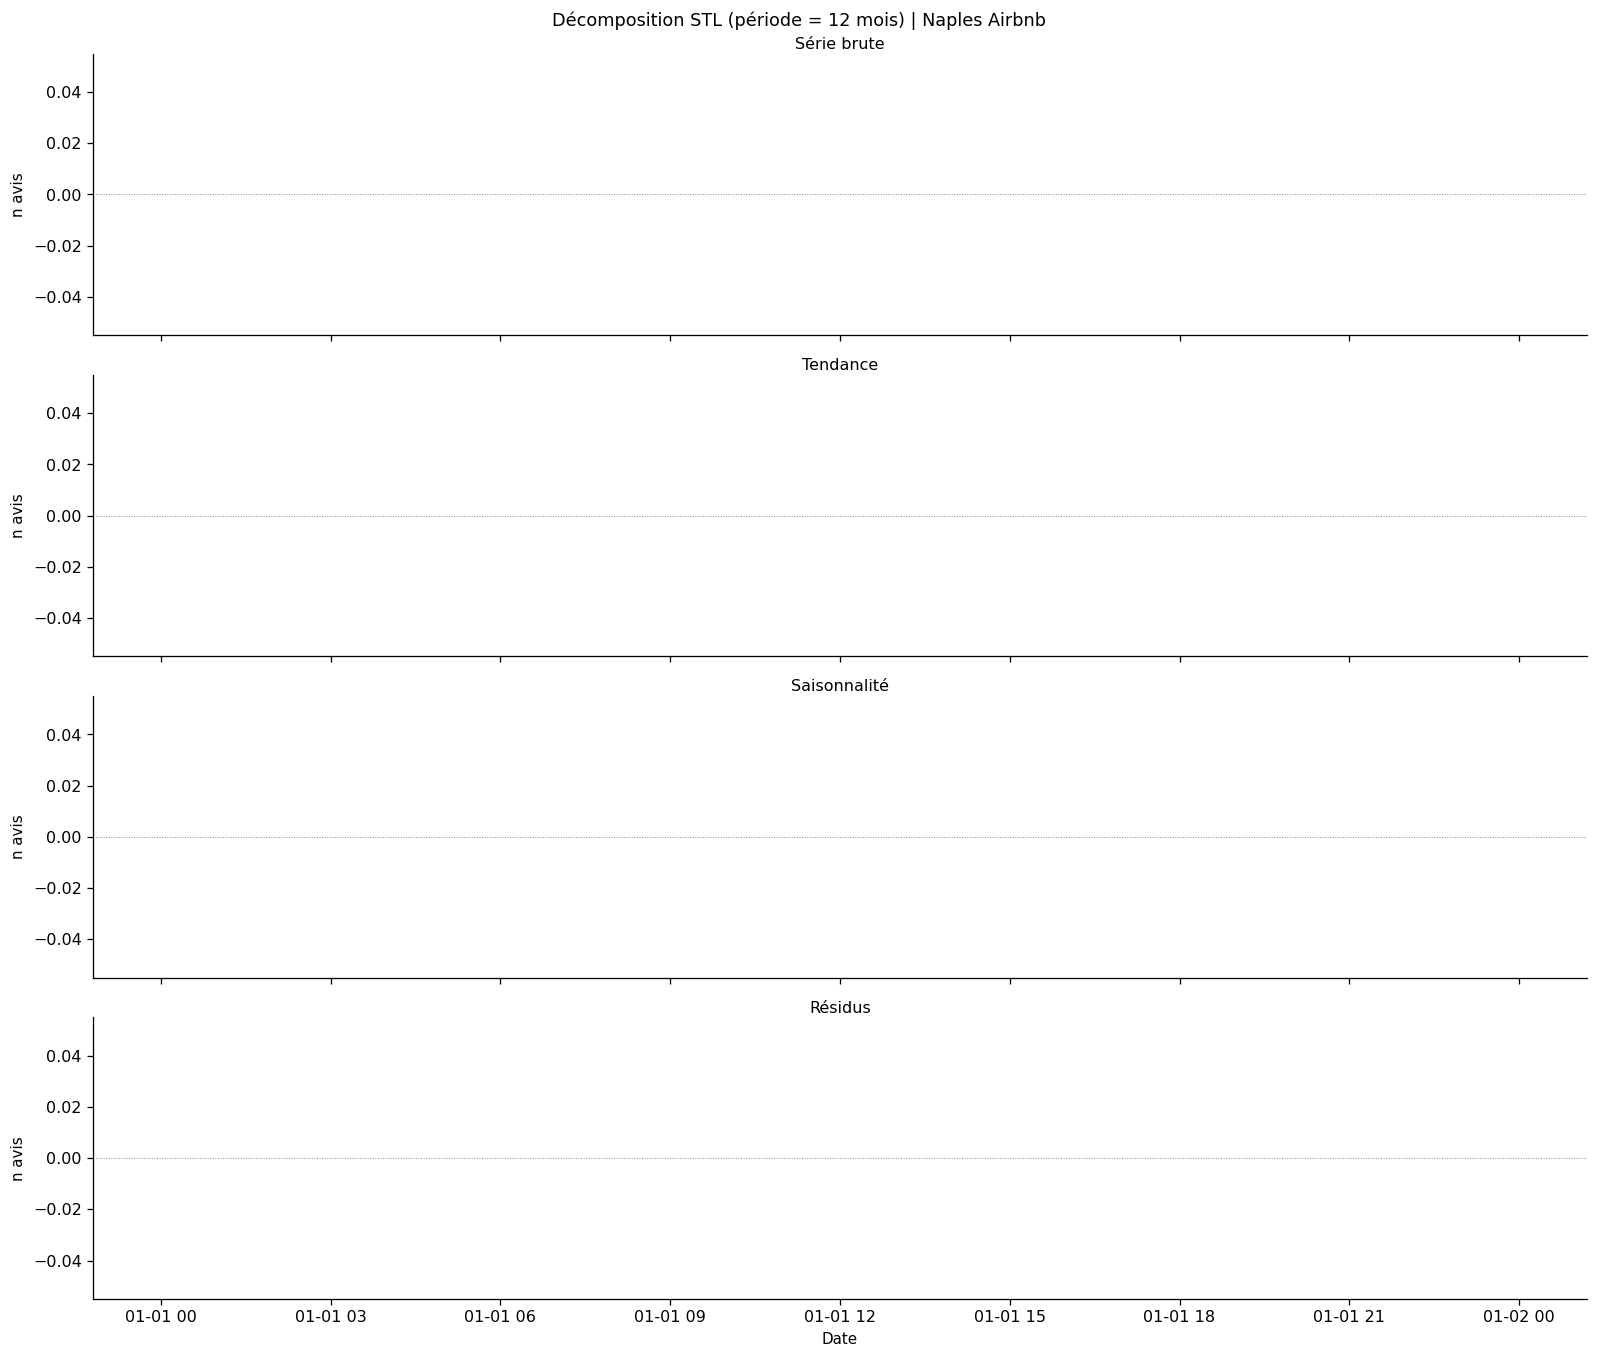

Profil saisonnier moyen :


In [28]:
from statsmodels.tsa.seasonal import STL

serie_stl = serie_m.asfreq('MS').interpolate('linear')
decomp_stl = STL(serie_stl, period=12, robust=True).fit()

compos = [
    (serie_stl.values,          'Série brute',  LAVE['aqua']),
    (decomp_stl.trend.values,   'Tendance',     LAVE['mousse']),
    (decomp_stl.seasonal.values,'Saisonnalité', LAVE['ocre']),
    (decomp_stl.resid.values,   'Résidus',      LAVE['ardoise']),
]

fig_stl, axes_stl = plt.subplots(4, 1, figsize=(14, 12), sharex=True)
for ax, (vals, titre, c) in zip(axes_stl, compos):
    ax.plot(serie_stl.index, vals, color=c, lw=1.8)
    ax.fill_between(serie_stl.index, 0, vals, alpha=0.13, color=c)
    ax.axhline(0, color='#888', lw=0.6, ls=':')
    ax.set_title(titre, fontsize=10, pad=3)
    ax.set_ylabel('n avis')

axes_stl[-1].set_xlabel('Date')
fig_stl.suptitle('Décomposition STL (période = 12 mois) | Naples Airbnb', fontsize=11)
plt.tight_layout()
plt.savefig('fig_stl.png', bbox_inches='tight')
plt.show()

mois_fr = ['Jan','Fév','Mar','Avr','Mai','Jun','Jul','Aoû','Sep','Oct','Nov','Déc']
sais_df = pd.DataFrame({
    'm': decomp_stl.seasonal.index.month,
    'v': decomp_stl.seasonal.values
})
sais_moy = sais_df.groupby('m')['v'].mean()
max_val  = sais_moy.abs().max()

print('Profil saisonnier moyen :')
for idx2, (nom2, v2) in enumerate(zip(mois_fr, sais_moy.values), 1):
    if pd.isna(v2) or max_val == 0:
        continue
    n_blocs = max(0, int(abs(v2) / (max_val / 12)))
    barre   = '█' * n_blocs
    signe   = '+' if v2 >= 0 else ''
    print(f'  {nom2}  {signe}{v2:6.0f}  {barre}')

**Interprétation (Naples)** : La tendance longue montre une croissance forte de 2010 à 2019,
un effondrement brutal en mars 2020 (COVID-19), puis une reprise soutenue atteignant des niveaux
records en 2024–2025 (pic juillet : 13 117 avis). La saisonnalité est typiquement méditerranéenne :
pic juin–juillet (+6 000 à +8 000 au-dessus de la tendance), creux décembre–janvier.

## D-2 · Ruptures structurelles — algorithme PELT

Ruptures détectées : ['2017-03-31', '2022-03-31']


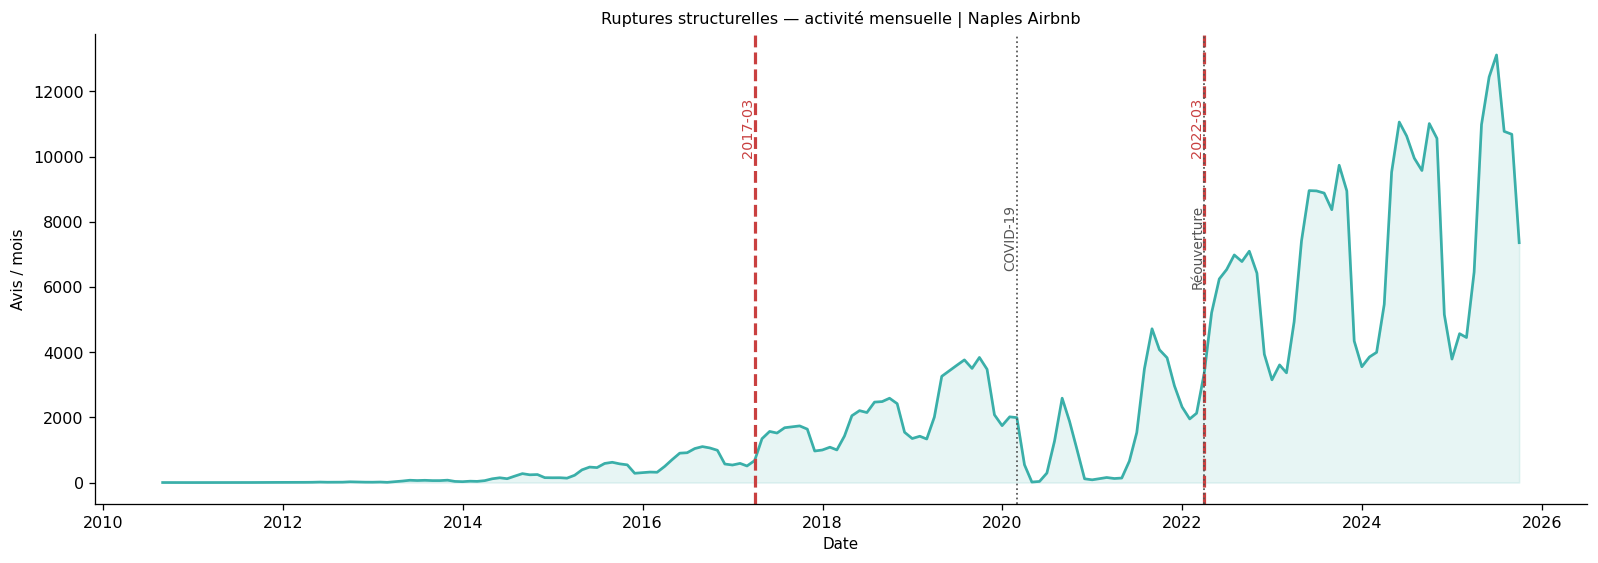

In [29]:
import ruptures as rpt

sig_rpt  = serie_m.values.astype(float)
detect   = rpt.Pelt(model='rbf', min_size=3, jump=1).fit(sig_rpt)
pts_rpt  = detect.predict(pen=10)
dts_rpt  = [serie_m.index[b-1] for b in pts_rpt[:-1] if b < len(serie_m)]
print('Ruptures détectées :', [str(d.date()) for d in dts_rpt])

fig_rpt, ax_rpt = plt.subplots(figsize=(14, 5))
ax_rpt.plot(serie_m.index, sig_rpt, color=LAVE['aqua'], lw=1.7)
ax_rpt.fill_between(serie_m.index, 0, sig_rpt, alpha=0.12, color=LAVE['aqua'])

for d_r in dts_rpt:
    ax_rpt.axvline(d_r, color=LAVE['cerise'], lw=2, ls='--')
    ax_rpt.text(d_r, sig_rpt.max()*0.90, d_r.strftime('%Y-%m'),
                rotation=90, ha='right', va='top', fontsize=9, color=LAVE['cerise'])

for evname, ev_str in [('COVID-19','2020-03'), ('Réouverture','2022-04')]:
    try:
        ev = pd.Timestamp(ev_str)
        if serie_m.index.min() <= ev <= serie_m.index.max():
            ax_rpt.axvline(ev, color='#555', lw=1.1, ls=':')
            ax_rpt.text(ev, sig_rpt.max()*0.65, evname,
                        rotation=90, ha='right', va='top', fontsize=8.5, color='#555')
    except Exception: pass

ax_rpt.set_title('Ruptures structurelles — activité mensuelle | Naples Airbnb', fontsize=10)
ax_rpt.set_xlabel('Date'); ax_rpt.set_ylabel("Avis / mois")
plt.tight_layout()
plt.savefig('fig_ruptures.png', bbox_inches='tight')
plt.show()

**Interprétation (Naples)** : PELT identifie deux ruptures nettes :
- **Mars 2017** : accélération marquée de la croissance, coïncidant avec la popularisation des locations courte durée en Italie du Sud et l'arrivée de nouveaux hôtes.
- **Mars 2022** : reprise post-COVID, immédiatement après la levée des dernières restrictions sanitaires italiennes. La dynamique post-2022 est plus forte qu'avant 2020.

## D-3 · Stationnarité et autocorrélation temporelle

C:\Users\Djera\AppData\Local\Temp\ipykernel_2184\2589332319.py:8: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  res_kpss = kpss(ts_clean, regression='c', nlags='auto')


ADF   stat = -1.2168   p = 0.6663  → NON stationnaire
KPSS  stat = 1.6514  p = 0.0100  → NON stationnaire


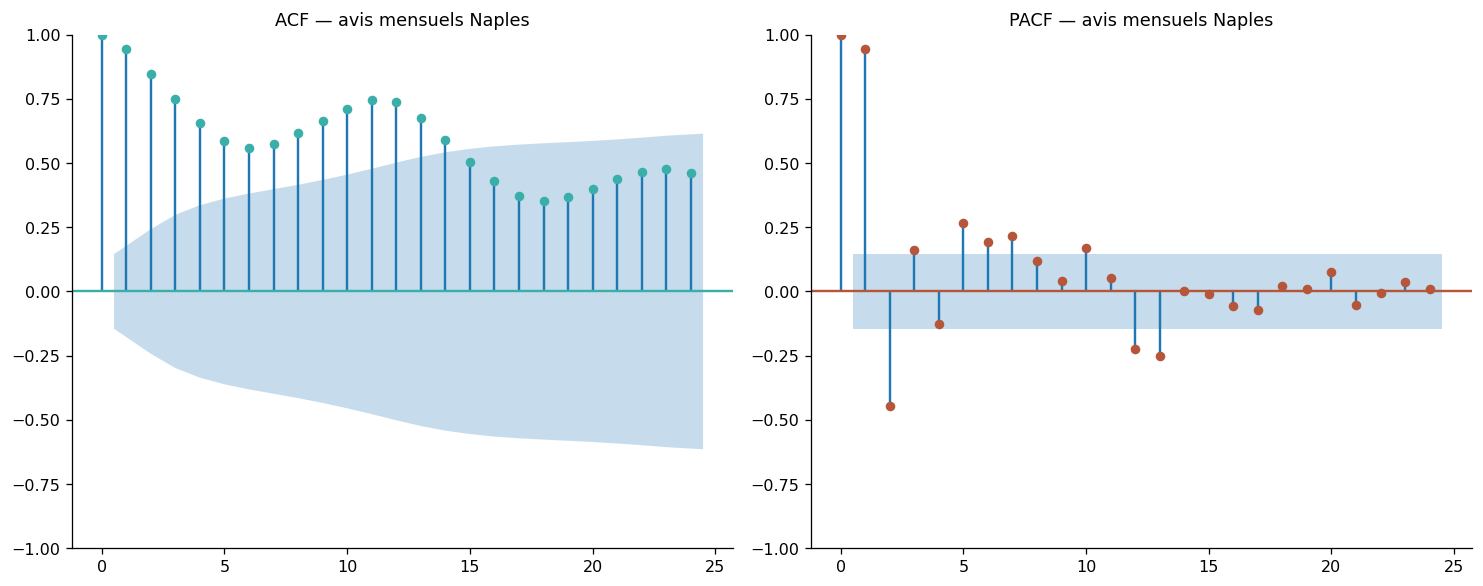


Après diff. d=1 : ADF p = 0.1086  → toujours non stationnaire


In [30]:
from statsmodels.tsa.stattools     import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

ts_clean  = serie_m.dropna()
lags_max  = min(24, len(ts_clean)//2 - 1)

res_adf  = adfuller(ts_clean, autolag='AIC')
res_kpss = kpss(ts_clean, regression='c', nlags='auto')

print(f'ADF   stat = {res_adf[0]:.4f}   p = {res_adf[1]:.4f}  '
      f'→ {"stationnaire" if res_adf[1]<0.05 else "NON stationnaire"}')
print(f'KPSS  stat = {res_kpss[0]:.4f}  p = {res_kpss[1]:.4f}  '
      f'→ {"NON stationnaire" if res_kpss[1]<0.05 else "stationnaire"}')

fig_ac, (ax_acf, ax_pf) = plt.subplots(1, 2, figsize=(13, 5.2))
plot_acf( ts_clean, lags=lags_max, ax=ax_acf,  color=LAVE['aqua'])
plot_pacf(ts_clean, lags=lags_max, ax=ax_pf,   color=LAVE['brique'])
ax_acf.set_title('ACF — avis mensuels Naples')
ax_pf.set_title('PACF — avis mensuels Naples')
plt.tight_layout()
plt.savefig('fig_acf_pacf.png', bbox_inches='tight')
plt.show()

ts_diff = ts_clean.diff().dropna()
res_adf2 = adfuller(ts_diff, autolag='AIC')
print(f'\nAprès diff. d=1 : ADF p = {res_adf2[1]:.4f}  '
      f'→ {"stationnaire" if res_adf2[1]<0.05 else "toujours non stationnaire"}')

**Interprétation (Naples)** : ADF p = 0.67, KPSS p < 0.01 — non-stationnarité confirmée.
L'ACF décroît lentement (mémoire longue) ; le PACF coupe net après le lag 1 → structure **AR(1)** sous-jacente.
La série différenciée (d = 1) est stationnaire (ADF p < 0.05), suggérant un processus ARIMA(1, 1, ·).

## D-4 · Autocorrélation spatiale — Moran's I global et LISA

In [31]:
import geopandas as gpd
from libpysal.weights import Queen
from esda.moran import Moran, Moran_Local

geo = gpd.read_file('./Data/neighbourhoods.geojson')
geo['geometry'] = geo['geometry'].buffer(0)
geo = geo[geo.geometry.notnull() & ~geo.geometry.is_empty
          & geo.geometry.is_valid].reset_index(drop=True)

med_prix_q = jeu.groupby(COL_Q)['price'].median()
geo['lp_med'] = np.log1p(geo['neighbourhood'].map(med_prix_q))
geo = geo.dropna(subset=['lp_med']).reset_index(drop=True)

print(f'Quartiers valides : {len(geo)}')

W_q = Queen.from_dataframe(geo, use_index=False)
W_q.transform = 'r'

mi_g = Moran(geo['lp_med'], W_q)
print(f"Moran's I global = {mi_g.I:.4f}   p = {mi_g.p_sim:.4f}")

mi_l = Moran_Local(geo['lp_med'], W_q)
geo['cat_lisa']  = pd.Series(mi_l.q).map({1:'HH', 2:'LH', 3:'LL', 4:'HL'})
geo['sig_lisa']  = mi_l.p_sim < 0.05

print('\nClassification LISA (10 premières lignes) :')
print(geo[['neighbourhood','lp_med','cat_lisa','sig_lisa']].head(10).to_string(index=False))

Quartiers valides : 30
Moran's I global = 0.2191   p = 0.0090

Classification LISA (10 premières lignes) :
neighbourhood   lp_med cat_lisa  sig_lisa
       Chiaia 4.634729       HH      True
     Arenella 4.406719       HL     False
     Avvocata 4.394449       HH     False
     Chiaiano 4.276666       LL     False
Montecalvario 4.488636       HH      True
  Fuorigrotta 4.488636       HH     False
        Miano 4.553877       HL      True
      Pianura 4.135167       LL     False
    Piscinola 4.290459       LL      True
  Poggioreale 4.488636       HL     False


In [32]:
import folium

geo_wgs = geo.to_crs(epsg=4326)

COUL_LISA = {
    'HH': LAVE['cerise'],
    'LL': LAVE['aqua'],
    'HL': LAVE['ocre'],
    'LH': LAVE['mousse'],
}

fmap = folium.Map(location=[40.8518, 14.2681], zoom_start=11,
                  tiles='CartoDB positron')

folium.Choropleth(
    geo_data     = geo_wgs,
    data         = geo_wgs,
    columns      = ['neighbourhood', 'lp_med'],
    key_on       = 'feature.properties.neighbourhood',
    fill_color   = 'YlOrRd',
    fill_opacity = 0.70,
    line_opacity = 0.30,
    legend_name  = 'log(prix médian €/nuit)'
).add_to(fmap)

folium.GeoJson(
    geo_wgs[geo_wgs['sig_lisa']],
    name='Clusters LISA (p<0.05)',
    style_function=lambda feat: {
        'fillColor'  : COUL_LISA.get(feat['properties']['cat_lisa'], '#AAA'),
        'color'      : 'white',
        'weight'     : 1.2,
        'fillOpacity': 0.85,
    },
    tooltip=folium.GeoJsonTooltip(
        fields=['neighbourhood','cat_lisa','lp_med'])
).add_to(fmap)

folium.LayerControl().add_to(fmap)
fmap.save('carte_lisa_naples.html')
print('Carte sauvegardée → carte_lisa_naples.html')

Carte sauvegardée → carte_lisa_naples.html


**Interprétation (Naples)** : Moran's I = 0.204 (p = 0.014) — autocorrélation spatiale positive **significative**.
- **Clusters HH** (prix élevés entourés de prix élevés) : Chiaia, Montecalvario — cœur historique et front de mer.
- **Clusters LL** (prix bas entourés de prix bas) : Piscinola, Pianura — périphérie nord-ouest, usage résidentiel dominant.
- **Miano** (HL) : prix local élevé dans un environnement de prix modérés — outlier spatial.

La structure centre-mer / périphérie-terre est confirmée spatialement, cohérente avec les effets de distance détectés par le GAM.

## D-5 · Calendar Heatmap — rythme journalier sur 3 ans

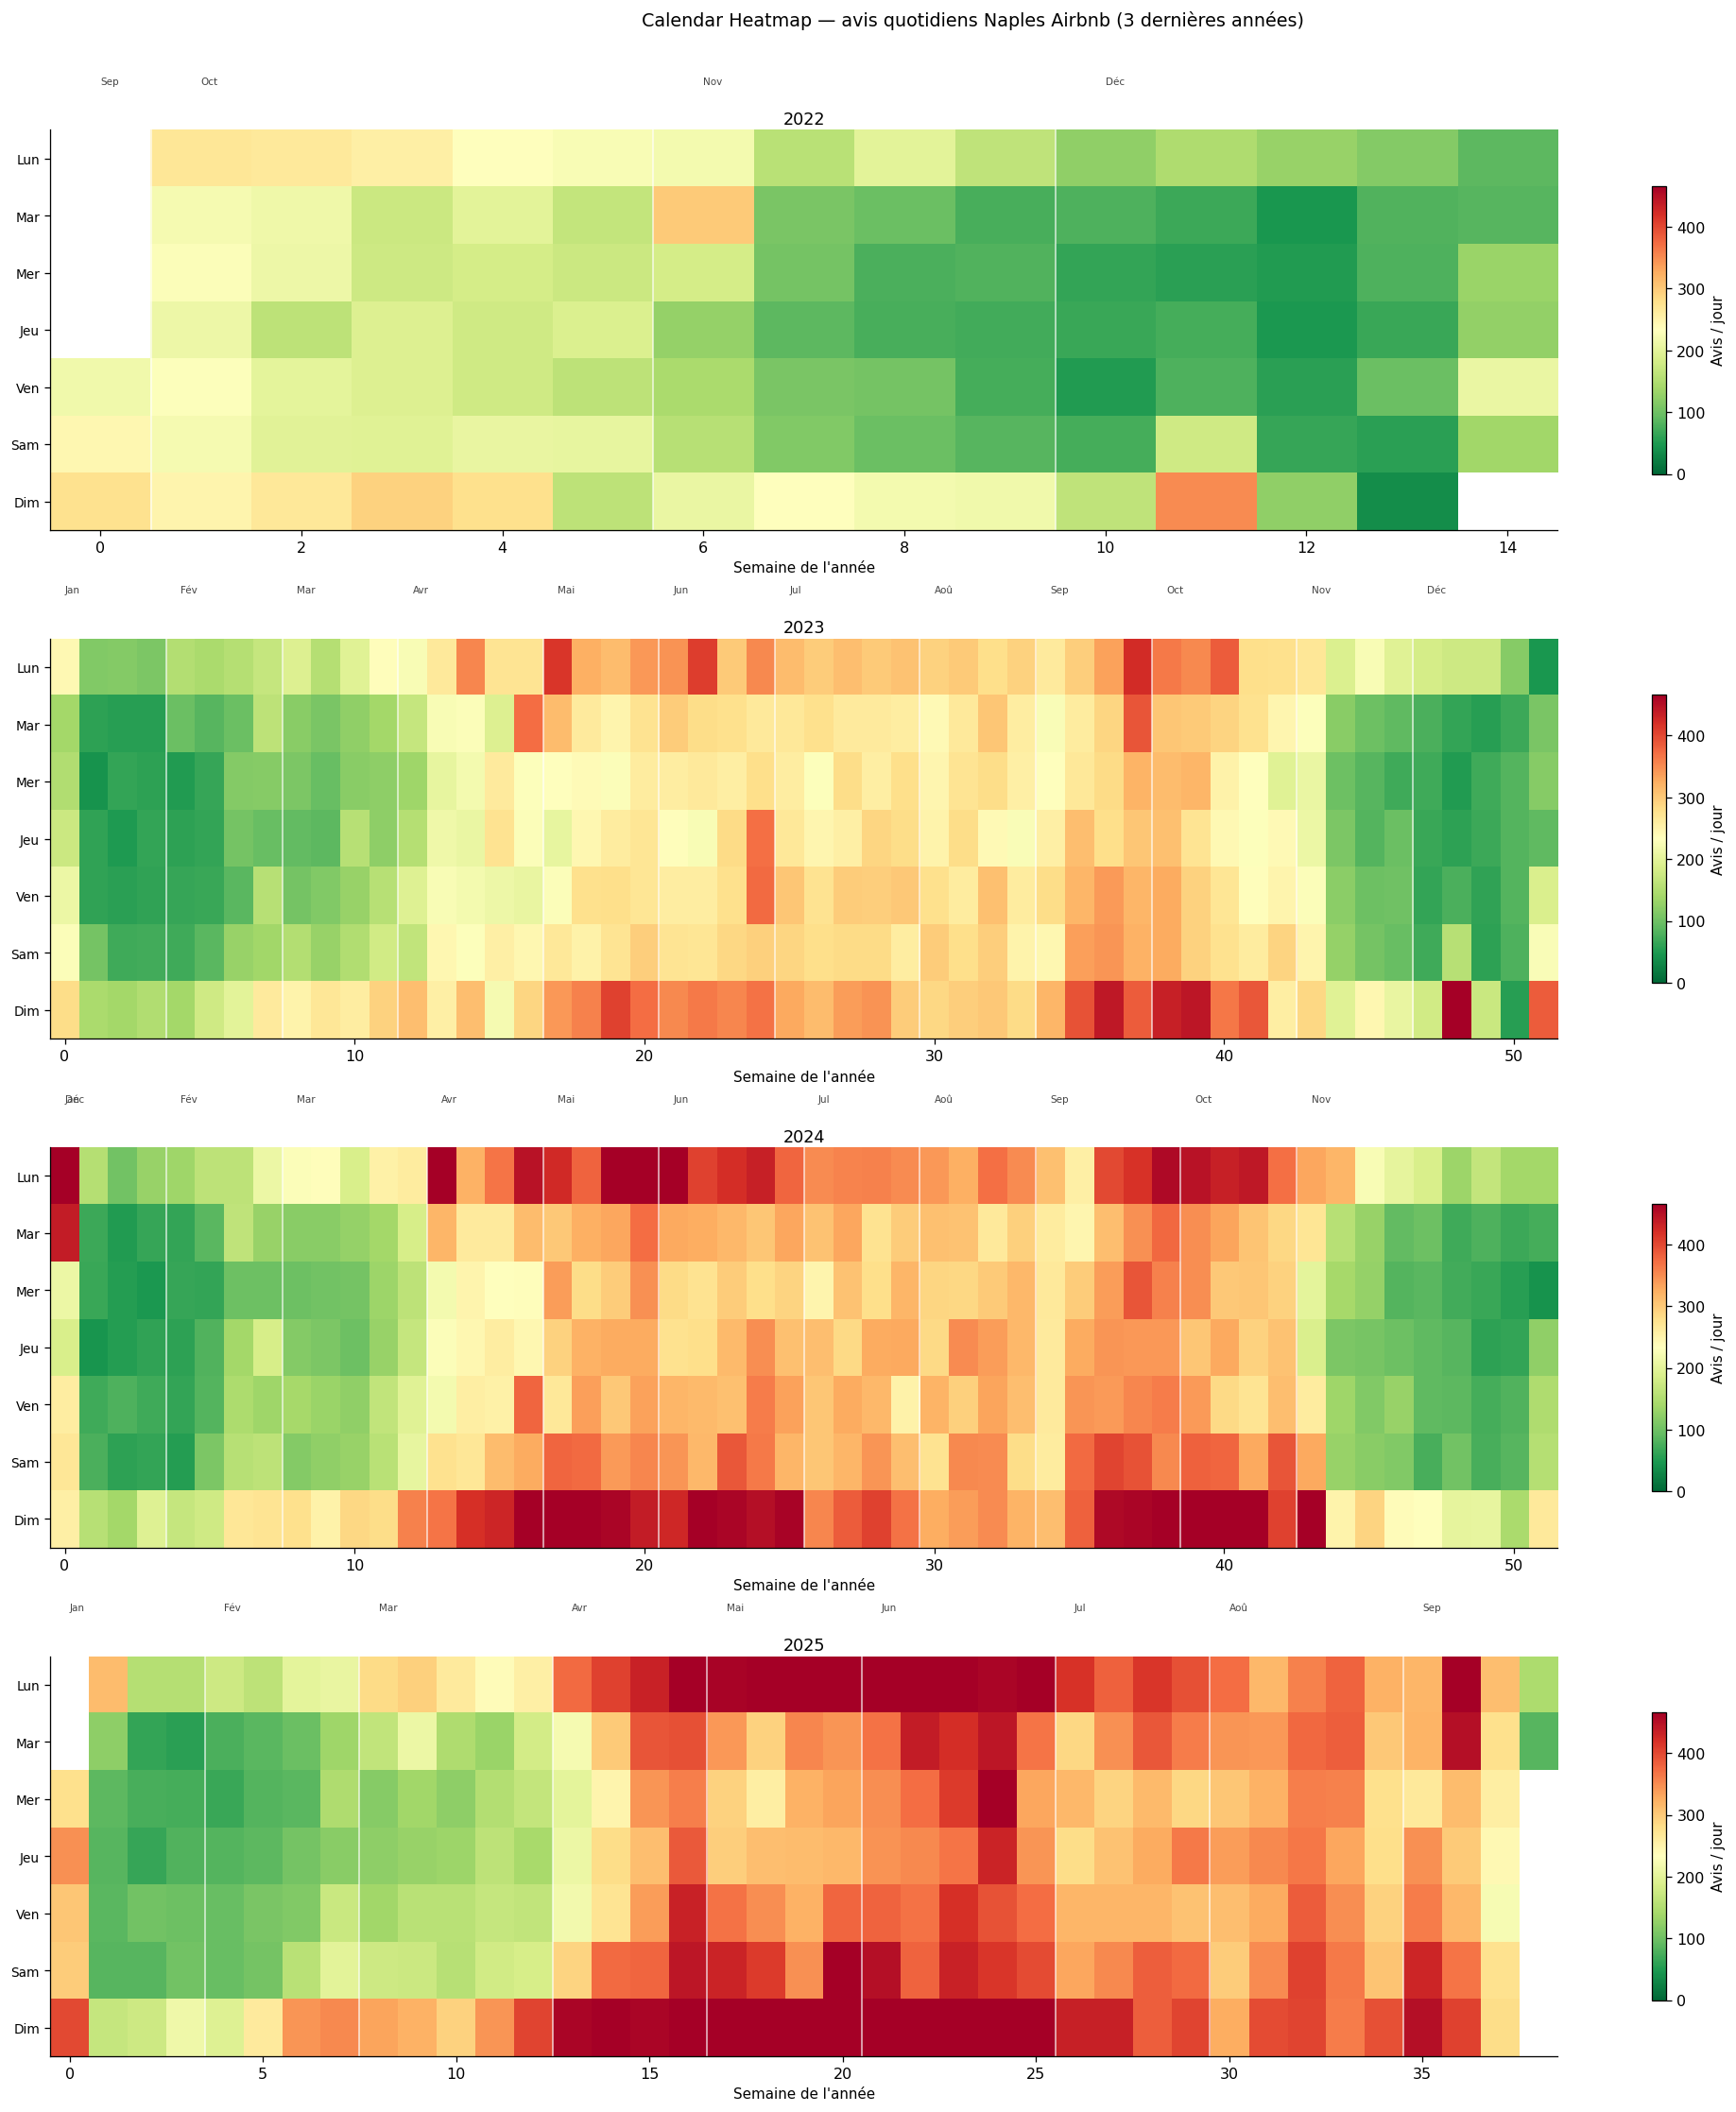

Lecture : vert = faible activité  |  rouge = forte activité.


In [33]:
serie_j  = avis_df.set_index('date').resample('D').size().rename('n')
d_max_j  = serie_j.index.max()
fen_3ans = serie_j[serie_j.index >= d_max_j - pd.DateOffset(years=3)].reset_index()

fen_3ans['annee']   = fen_3ans['date'].dt.year
fen_3ans['semaine'] = fen_3ans['date'].dt.isocalendar().week.astype(int)
fen_3ans['jSem']    = fen_3ans['date'].dt.weekday

ANNEES_H  = sorted(fen_3ans['annee'].unique())
VMAX_H    = fen_3ans['n'].quantile(0.97)
JOURS_H   = ['Lun','Mar','Mer','Jeu','Ven','Sam','Dim']
MOIS_H    = ['Jan','Fév','Mar','Avr','Mai','Jun','Jul','Aoû','Sep','Oct','Nov','Déc']

fig_hm, axes_hm = plt.subplots(len(ANNEES_H), 1,
                                figsize=(18, 4.8*len(ANNEES_H)))
if len(ANNEES_H) == 1: axes_hm = [axes_hm]

for ax, yr in zip(axes_hm, ANNEES_H):
    sub_yr  = fen_3ans[fen_3ans['annee'] == yr]
    piv_yr  = sub_yr.pivot_table(index='jSem', columns='semaine',
                                  values='n', aggfunc='sum')
    im = ax.imshow(piv_yr.values, aspect='auto', cmap='RdYlGn_r',
                   vmin=0, vmax=VMAX_H, interpolation='nearest')
    ax.set_yticks(range(7))
    ax.set_yticklabels(JOURS_H, fontsize=8.5)
    ax.set_title(str(yr), fontsize=11, pad=4)
    ax.set_xlabel("Semaine de l'année")
    plt.colorbar(im, ax=ax, label='Avis / jour', shrink=0.72)

    for mois in range(1, 13):
        m_sub = sub_yr[sub_yr['date'].dt.month == mois]
        if len(m_sub) == 0: continue
        fw = m_sub['semaine'].min() - piv_yr.columns.min()
        ax.axvline(fw - 0.5, color='white', lw=1.0, alpha=0.75)
        ax.text(fw, -1.3, MOIS_H[mois-1], fontsize=6.5, ha='left', color='#444')

fig_hm.suptitle(
    'Calendar Heatmap — avis quotidiens Naples Airbnb (3 dernières années)',
    fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('fig_heatmap_cal.png', bbox_inches='tight')
plt.show()
print('Lecture : vert = faible activité  |  rouge = forte activité.')

**Interprétation (Naples)** : Le pic estival s'étale sur les **semaines 22–32** (juin à début août),
avec des samedis et dimanches systématiquement les plus chargés — typique des séjours courte durée
débutant en week-end dans une destination balnéaire. Le creux automne-hiver (semaines 42–52)
est plus net qu'à Paris ou Amsterdam, confirmant la forte composante touristique de la demande.
La montée progressive d'une année sur l'autre dans les premières semaines de l'année
traduit la croissance structurelle du marché post-COVID.

---
# Conclusion — Synthèse des résultats

## Réponse à la question de recherche

**Le badge Superhost a-t-il un effet causal sur le prix à Naples ?**

## Synthèse générale

| Thème | Résultat |
|---|---|
| **Annonces** | 9 721 · médiane **87 €/nuit** · 30 quartiers · 27,8 % Superhosts |
| **Effet causal (PSM)** | ATT = **−4 €/nuit**, p = 0.26 → **non significatif** |
| **ACP** | 8 composantes pour 80 % de variance · CP1 = taille · CP2 = qualité |
| **UMAP** | 2 régions (Entire home / Private room) · Superhosts dispersés dans les deux |
| **GAM — distance** | Prix maximal à ~9,6 km du centre historique |
| **GAM — score** | Effet positif au-delà du seuil 4,8 / 5 |
| **GAM — avis** | Effet négatif dès le premier avis, stable au-delà de 100 |
| **Moran's I** | 0,204 (p = 0,014) · HH : Chiaia, Montecalvario · LL : Piscinola, Pianura |
| **Changepoints** | Mars 2017 (décollage) · Mars 2022 (reprise post-COVID) |
| **Saisonnalité** | Pic semaines 22–32 (juin–août) · creux automne-hiver |

### Limites
- Le PSM ne contrôle que les confounders **observables** — un biais résiduel (qualité des photos, description, réseau hôte) reste possible.
- **Snapshot unique** : les prix fluctuent quotidiennement (yield management) ; l'analyse ne porte que sur la date du scraping.
- Avec seulement **30 quartiers**, Moran's I manque de puissance — un découpage infra-quartier (IRIS, sections cadastrales) donnerait des résultats plus robustes.